# ==========================================================
# Sales Forecasting & Demand Intelligence System
# Author : Divesh Matkar
# Internship : XYlofy AI Week 3 & 4
# ==========================================================

# 1. Project Introduction

## End-to-End Sales Forecasting & Demand Intelligence System

### Objective

This project aims to build an intelligent demand forecasting system capable of:

- Forecasting future sales using multiple forecasting models.
- Detecting unusual sales behavior.
- Segmenting products based on demand.
- Helping businesses improve inventory planning.
- Deploying an interactive Streamlit dashboard.

---

### Dataset

Primary Dataset

- Superstore Sales Dataset

Secondary Dataset

- Video Game Sales Dataset

---

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Statsmodels
- Prophet
- XGBoost
- Scikit-Learn
- Streamlit

In [165]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [166]:
import warnings
warnings.filterwarnings("ignore")

In [167]:
# ======================================================
# Import Libraries
# ======================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from prophet import Prophet

from xgboost import XGBRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

from config import *

from utils.logger import logger
from utils.helper import *
from utils.visualization import *

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"]=(12,6)

logger.info("="*80)
logger.info("Libraries Imported Successfully")
logger.info("="*80)

In [168]:
# ======================================================
# Load Dataset
# ======================================================

logger.info("Loading Superstore Dataset...")

df = pd.read_csv(TRAIN_DATA)

logger.info(f"Dataset Shape : {df.shape}")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [169]:
rows, cols = df.shape

print(f"Number of Rows : {rows}")
print(f"Number of Columns : {cols}")

logger.info(f"Rows : {rows}")
logger.info(f"Columns : {cols}")

Number of Rows : 9800
Number of Columns : 18


In [170]:
logger.info("Checking Dataset Information")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [171]:
datatype = pd.DataFrame(df.dtypes, columns=["Data Type"])

datatype

,Data Type
Row ID,int64
Order ID,str
Order Date,str
Ship Date,str
Ship Mode,str
Customer ID,str
Customer Name,str
Segment,str
Country,str
City,str


In [172]:
logger.info("Generating Statistical Summary")

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9800.0,NaN,NaN,NaN,4900.5,2829.160653,1.0,2450.75,4900.5,7350.25,9800.0
Order ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9800,1230,05/09/2017,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9800,1326,26/09/2018,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [173]:
# ======================================================
# Missing Values
# ======================================================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean() * 100, 2)
})

missing = missing[missing["Missing Values"] > 0]

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Postal Code,11,0.11


In [174]:
logger.info("Handling Missing Postal Codes")

df["Postal Code"] = df["Postal Code"].fillna(
    df["Postal Code"].mode()[0]
)

logger.info("Missing Values Handled")

In [175]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

logger.info(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [176]:
logger.info("Converting Date Columns")

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True,   # remove if your dates are month/day/year
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

logger.info("Date Conversion Completed")

In [177]:
logger.info("Creating Time Features")

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Week"] = df["Order Date"].dt.isocalendar().week.astype("Int64")
df["Day"] = df["Order Date"].dt.day_name()

logger.info("Time Features Created")

In [178]:
season_map = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Summer",
    4: "Summer",
    5: "Summer",
    6: "Monsoon",
    7: "Monsoon",
    8: "Monsoon",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn"
}

df["Season"] = df["Month"].map(season_map)

In [179]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

logger.info("Shipping Days Feature Created")

In [180]:
df.to_csv(
    OUTPUT_DIR / "clean_superstore.csv",
    index=False
)

logger.info("Clean Dataset Saved")

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand sales patterns,
customer behavior,
regional performance,
seasonality,
and business opportunities before building forecasting models.

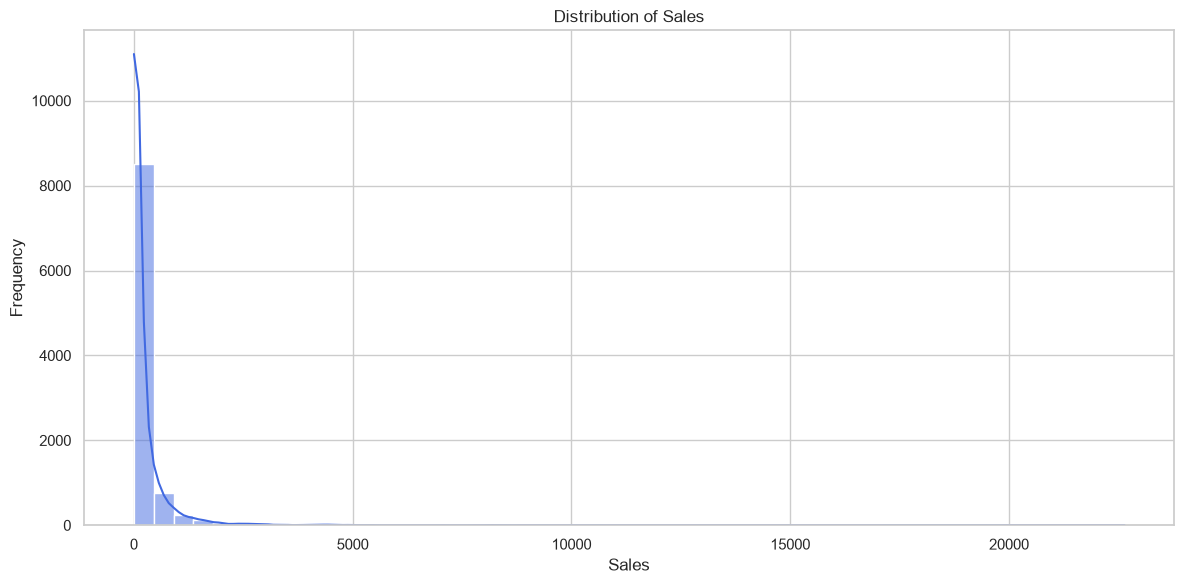

In [181]:
logger.info("Plotting Sales Distribution")

plt.figure(figsize=(12,6))

sns.histplot(

    df["Sales"],

    bins=50,

    kde=True,

    color="royalblue"

)

plt.title("Distribution of Sales")

plt.xlabel("Sales")

plt.ylabel("Frequency")

save_chart("01_sales_distribution")

Most sales are concentrated at lower values.

A few extremely large transactions create a long right tail.

The data is positively skewed.

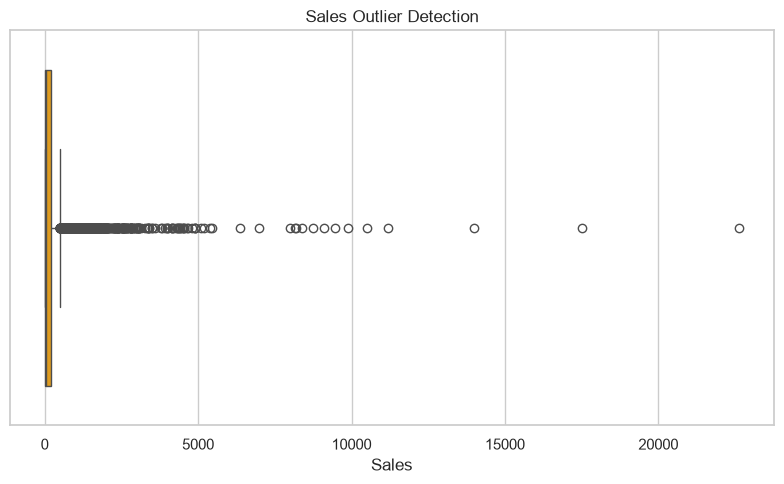

In [182]:
logger.info("Sales Boxplot")

plt.figure(figsize=(8,5))

sns.boxplot(

    x=df["Sales"],

    color="orange"

)

plt.title("Sales Outlier Detection")

save_chart("02_sales_boxplot")

Several high-value orders exist.

These are genuine business transactions,
not necessarily errors.

They should not be removed before forecasting.

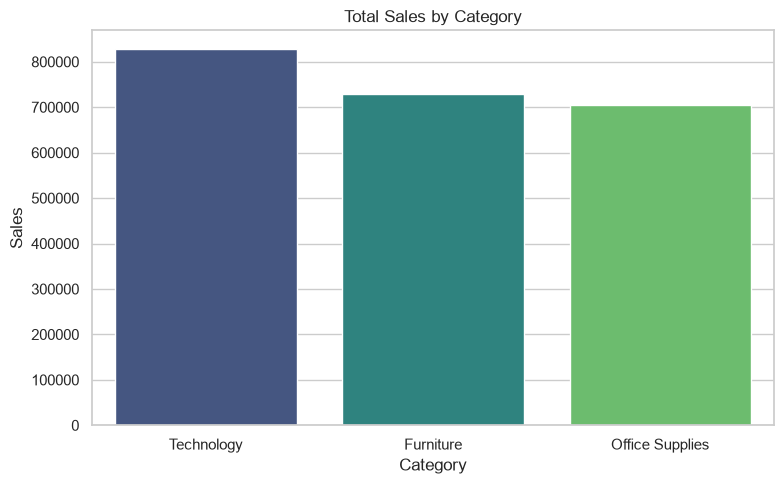

In [183]:
category_sales = (

    df.groupby("Category")["Sales"]

    .sum()

    .sort_values(ascending=False)

)

plt.figure(figsize=(8,5))

sns.barplot(

    x=category_sales.index,

    y=category_sales.values,

    palette="viridis"

)

plt.title("Total Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales")

save_chart("03_category_sales")

Technology contributes the highest revenue.

Furniture follows.

Office Supplies generate the least sales.

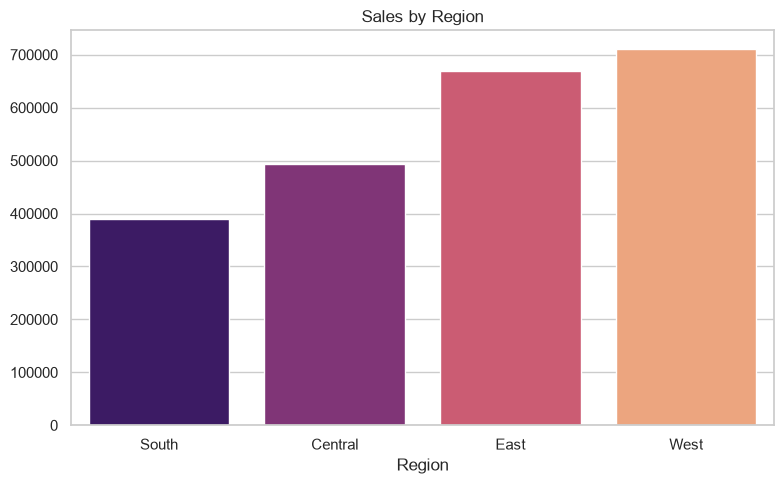

In [184]:
region_sales = (

    df.groupby("Region")["Sales"]

    .sum()

    .sort_values()

)

plt.figure(figsize=(8,5))

sns.barplot(

    x=region_sales.index,

    y=region_sales.values,

    palette="magma"

)

plt.title("Sales by Region")

save_chart("04_region_sales")

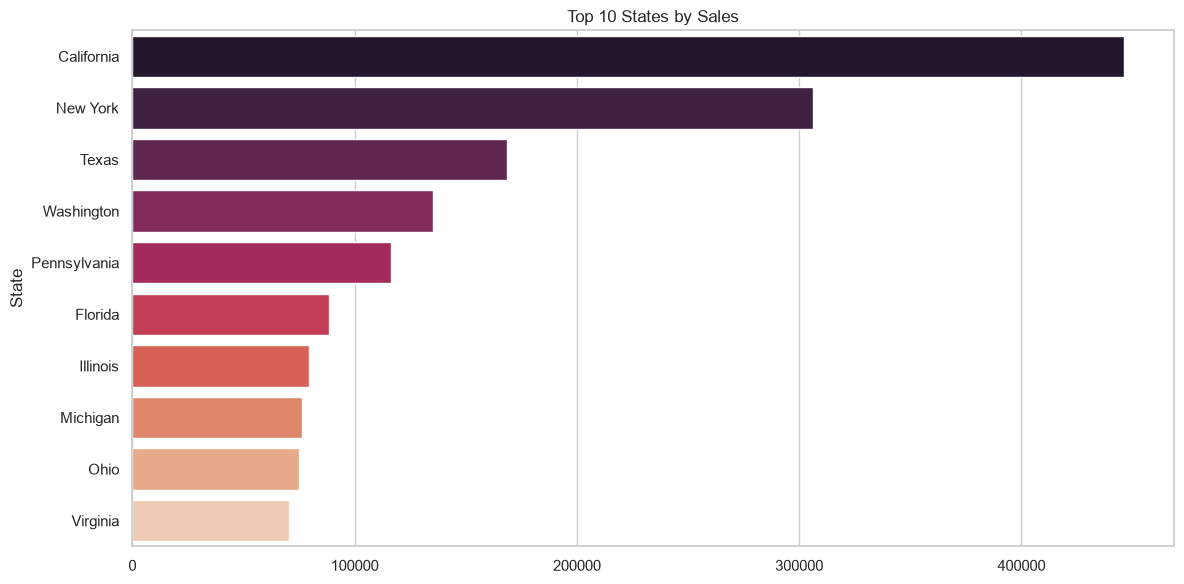

In [185]:
state_sales = (

    df.groupby("State")["Sales"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(12,6))

sns.barplot(

    x=state_sales.values,

    y=state_sales.index,

    palette="rocket"

)

plt.title("Top 10 States by Sales")

save_chart("05_top_states")

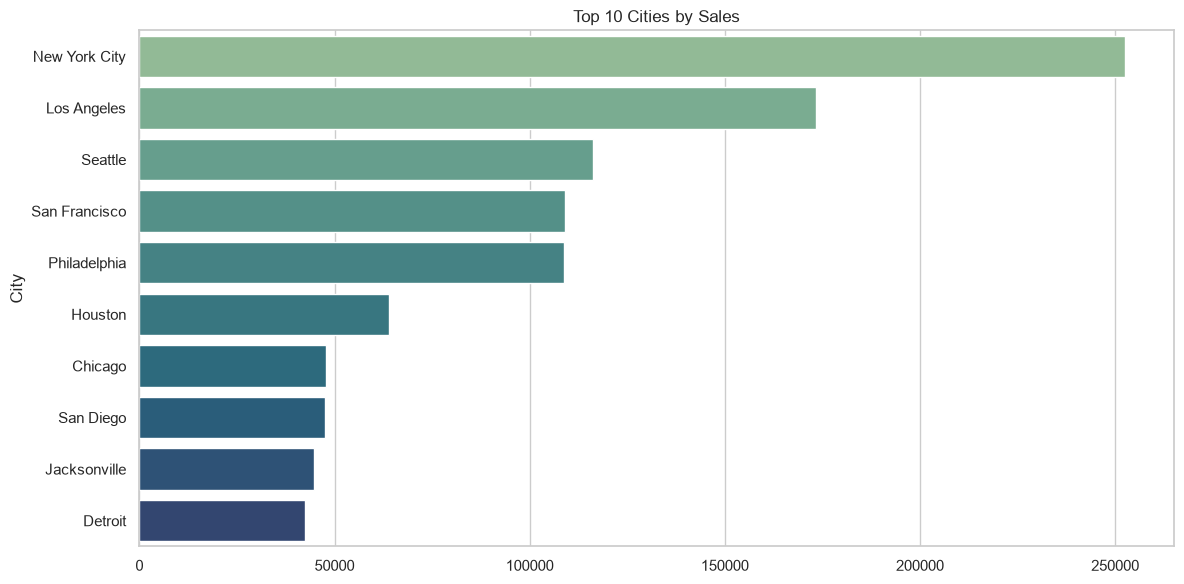

In [186]:
city_sales = (

    df.groupby("City")["Sales"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(12,6))

sns.barplot(

    x=city_sales.values,

    y=city_sales.index,

    palette="crest"

)

plt.title("Top 10 Cities by Sales")

save_chart("06_top_cities")

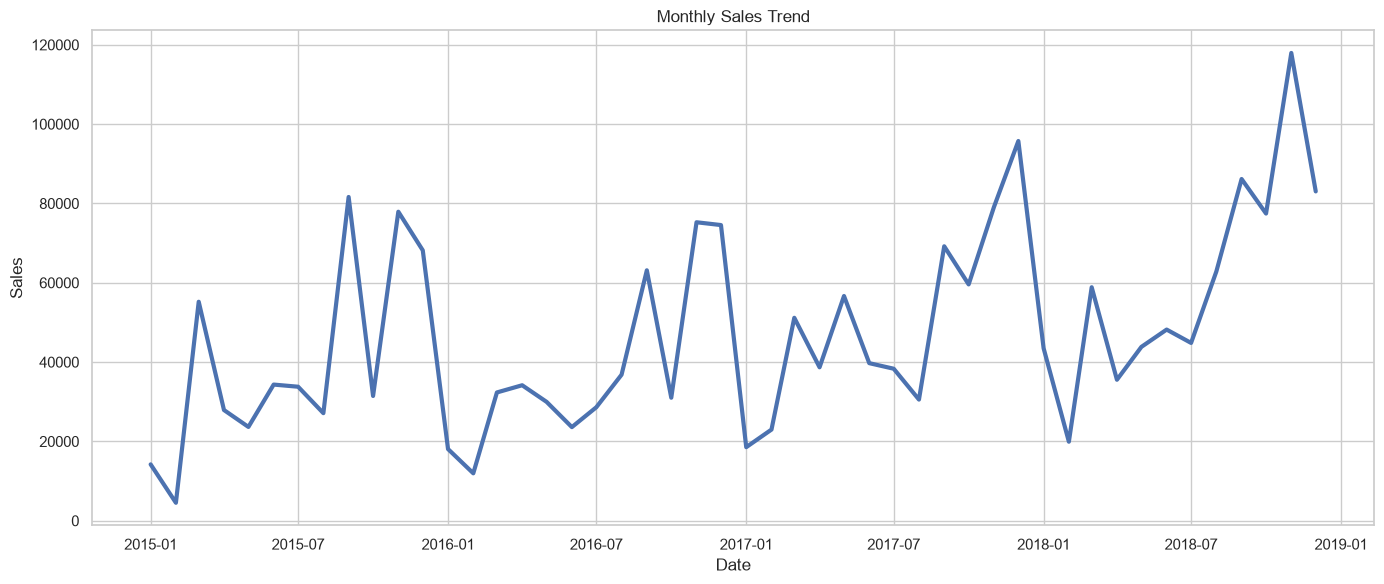

In [187]:
monthly = (

    df.groupby(["Year","Month"])["Sales"]

    .sum()

    .reset_index()

)

monthly["Date"] = pd.to_datetime(

    monthly["Year"].astype(str)

    + "-"

    + monthly["Month"].astype(str)

)

plt.figure(figsize=(14,6))

plt.plot(

    monthly["Date"],

    monthly["Sales"],

    linewidth=3

)

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

save_chart("07_monthly_sales")

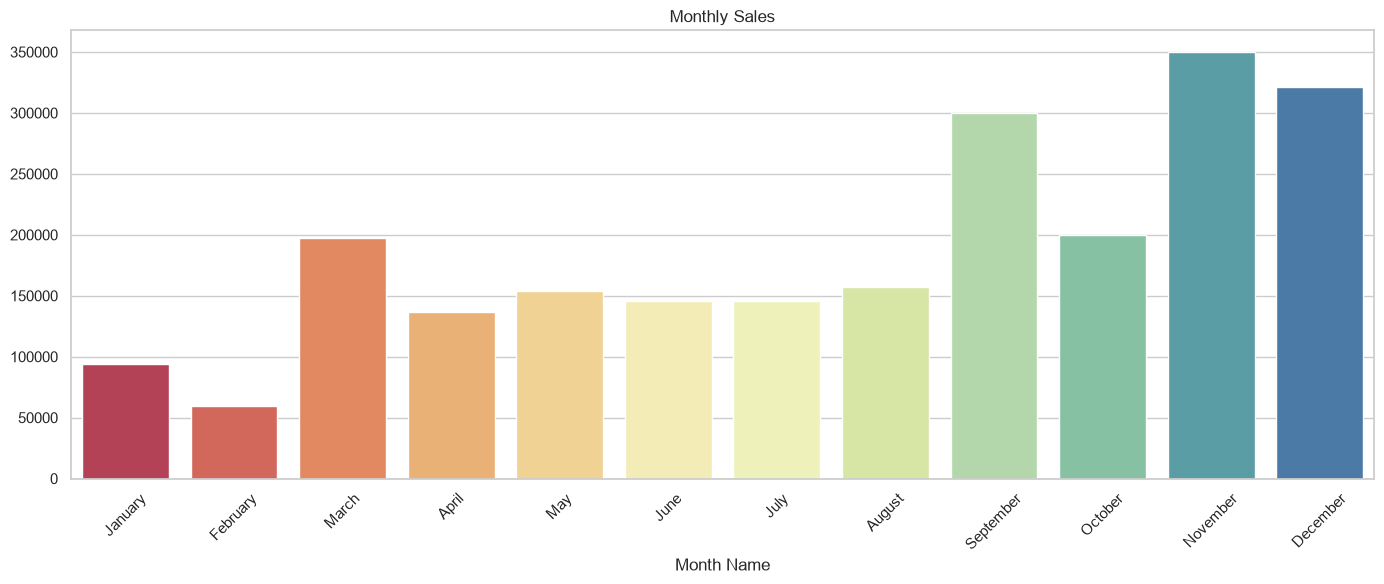

In [188]:
month_sales = (

    df.groupby("Month Name")["Sales"]

    .sum()

)

month_order = [

"January","February","March","April",

"May","June","July","August",

"September","October","November","December"

]

month_sales = month_sales.reindex(month_order)

plt.figure(figsize=(14,6))

sns.barplot(

    x=month_sales.index,

    y=month_sales.values,

    palette="Spectral"

)

plt.xticks(rotation=45)

plt.title("Monthly Sales")

save_chart("08_monthly_bar")

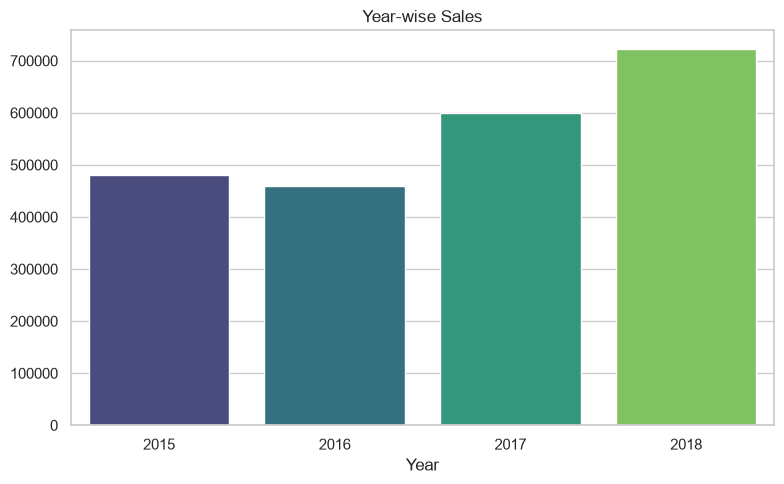

In [189]:
year_sales = (
    df.groupby("Year")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=year_sales.index,
    y=year_sales.values,
    palette="viridis"
)

plt.title("Year-wise Sales")

save_chart("09_year_sales")

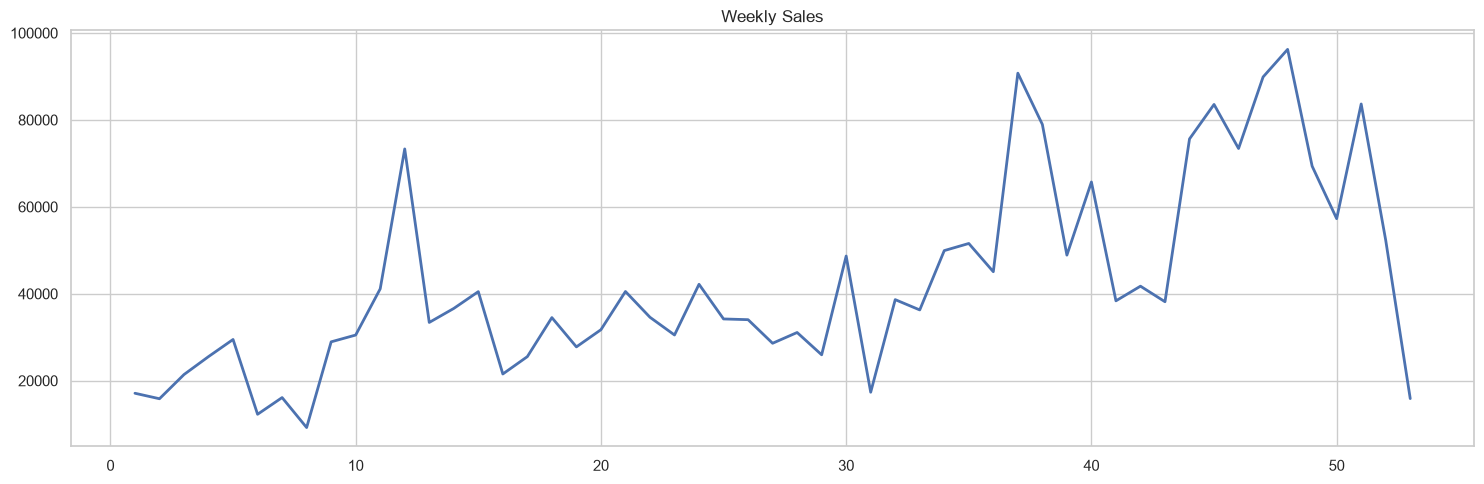

In [190]:
weekly = (
    df.groupby("Week")["Sales"]
    .sum()
)

plt.figure(figsize=(15,5))

plt.plot(
    weekly.index,
    weekly.values,
    linewidth=2
)

plt.title("Weekly Sales")

save_chart("10_week_sales")

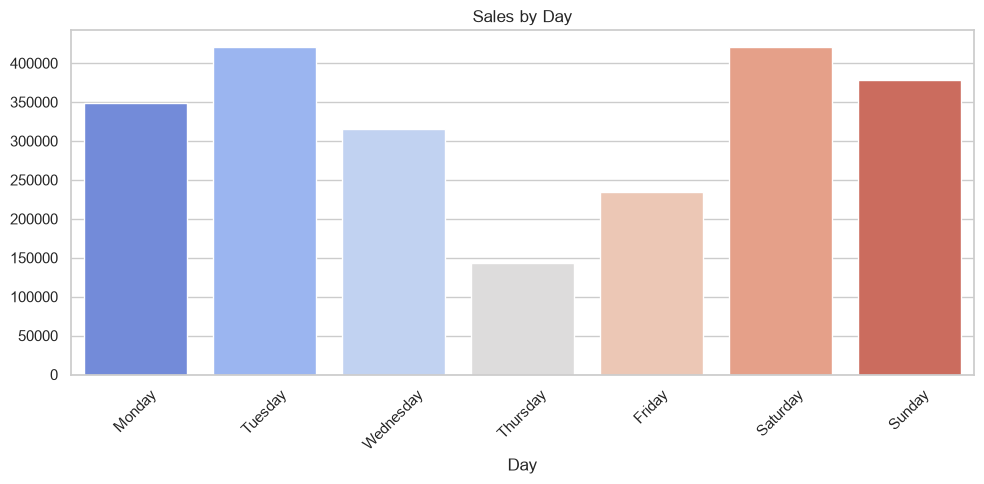

In [191]:
day = (
    df.groupby("Day")["Sales"]
    .sum()
)

order = [
"Monday",
"Tuesday",
"Wednesday",
"Thursday",
"Friday",
"Saturday",
"Sunday"
]

day = day.reindex(order)

plt.figure(figsize=(10,5))

sns.barplot(
    x=day.index,
    y=day.values,
    palette="coolwarm"
)

plt.xticks(rotation=45)

plt.title("Sales by Day")

save_chart("11_day_sales")

In [192]:

fig = px.treemap(

    df,

    path=["Category","Sub-Category"],

    values="Sales",

    color="Sales"

)

fig.write_image(
    CHART_DIR/"12_treemap.png"
)

fig.show()

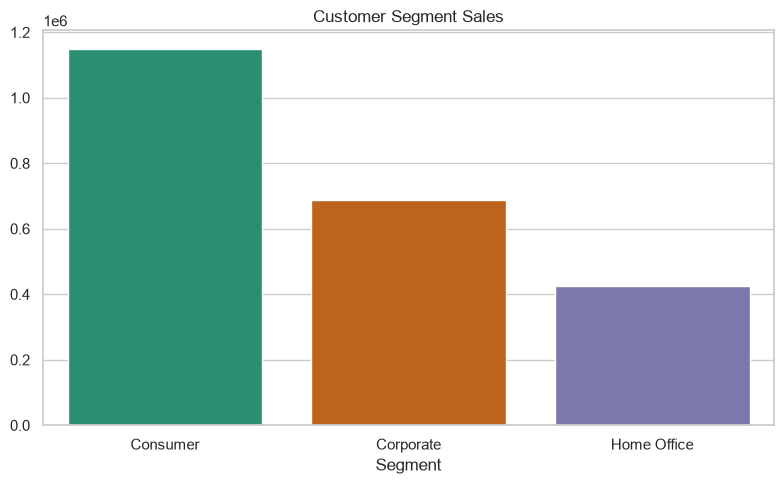

In [193]:
segment = (
    df.groupby("Segment")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment.index,
    y=segment.values,
    palette="Dark2"
)

plt.title("Customer Segment Sales")

save_chart("13_segment")

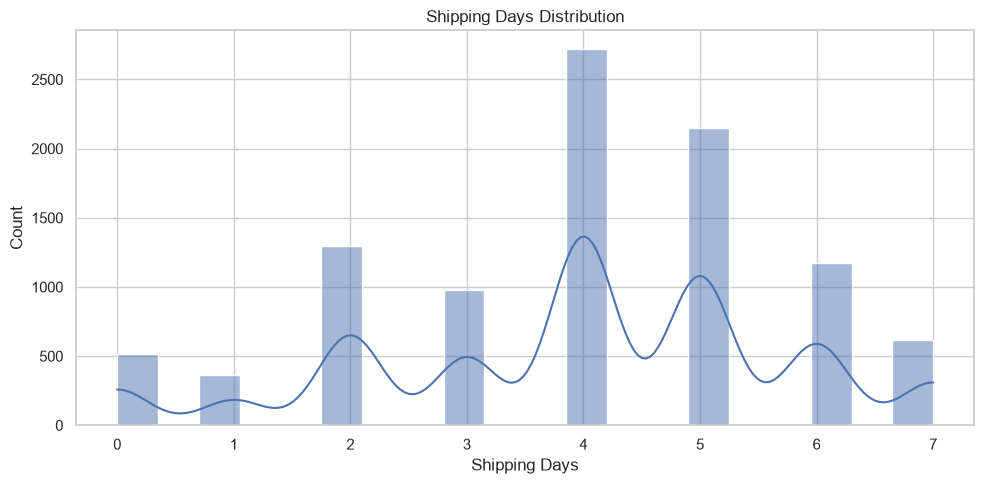

In [194]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Shipping Days"],
    bins=20,
    kde=True
)

plt.title("Shipping Days Distribution")

save_chart("14_shipping_days")

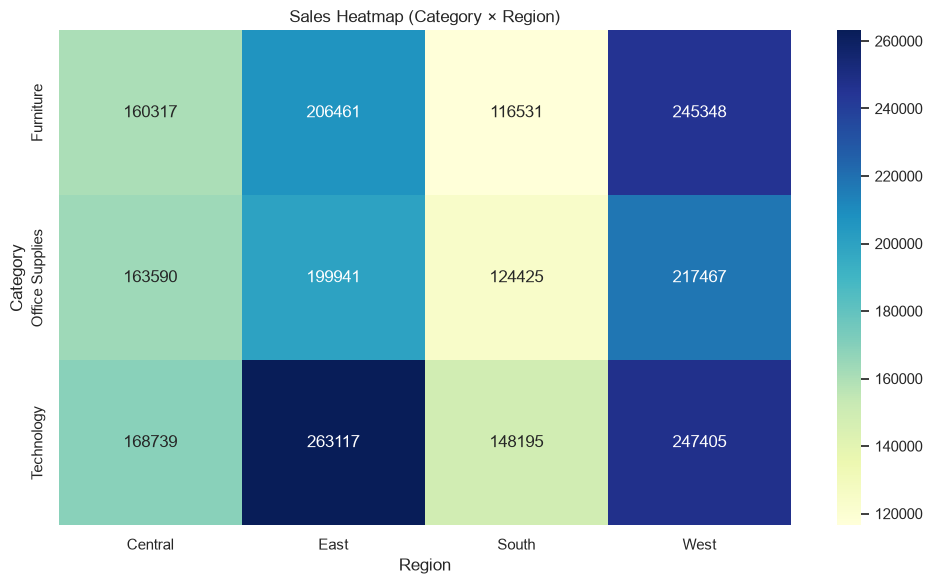

In [195]:
logger.info("Category vs Region Heatmap")

category_region = pd.pivot_table(
    df,
    values="Sales",
    index="Category",
    columns="Region",
    aggfunc="sum"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    category_region,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Sales Heatmap (Category × Region)")

save_chart("15_category_region_heatmap")

- Technology performs strongly across almost every region.
- Some regions contribute significantly less revenue.
- Regional demand varies by product category.

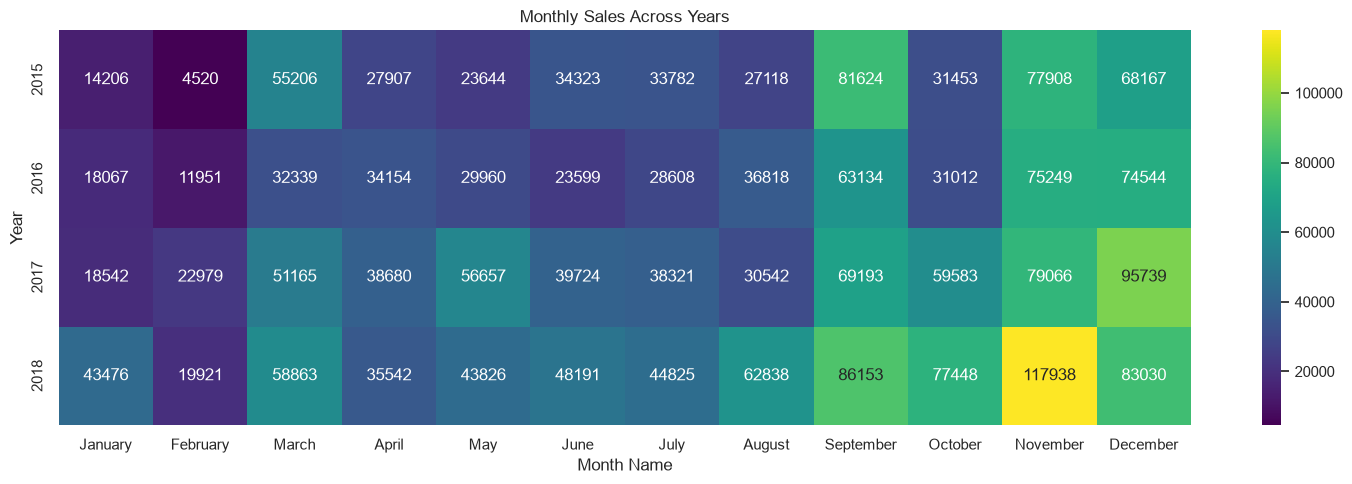

In [196]:
logger.info("Year-Month Heatmap")

year_month = pd.pivot_table(
    df,
    values="Sales",
    index="Year",
    columns="Month Name",
    aggfunc="sum"
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

year_month = year_month[month_order]

plt.figure(figsize=(15,5))

sns.heatmap(
    year_month,
    annot=True,
    fmt=".0f",
    cmap="viridis"
)

plt.title("Monthly Sales Across Years")

save_chart("16_year_month_heatmap")

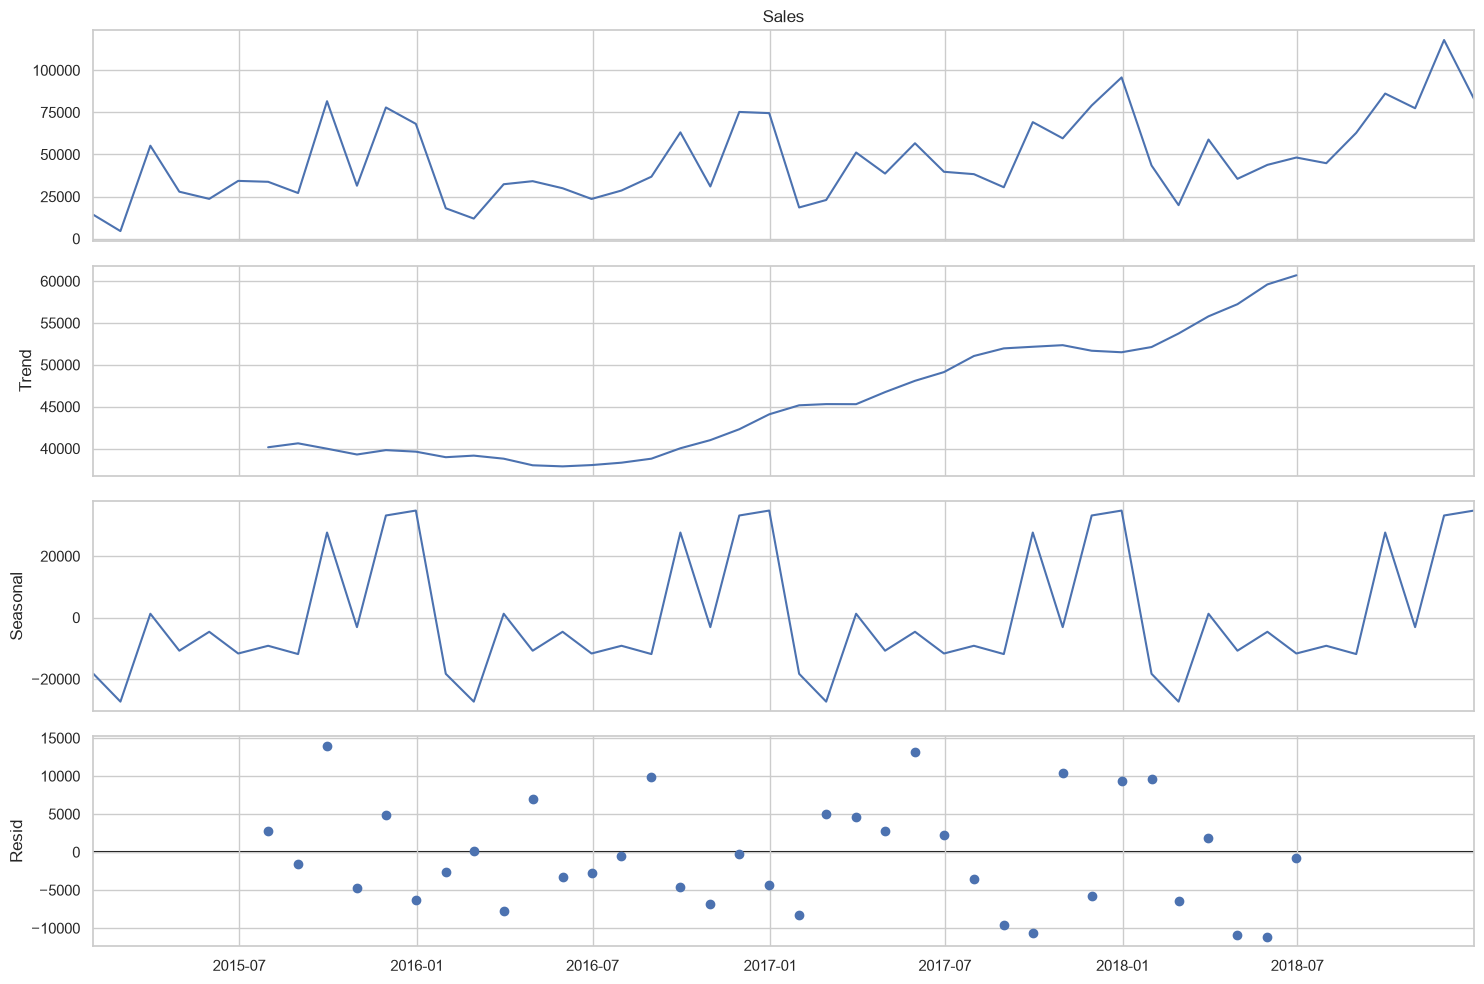

In [197]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.tight_layout()

plt.savefig(CHART_DIR/"17_time_series_decomposition.png", dpi=300)

plt.show()

<Figure size 1200x500 with 0 Axes>

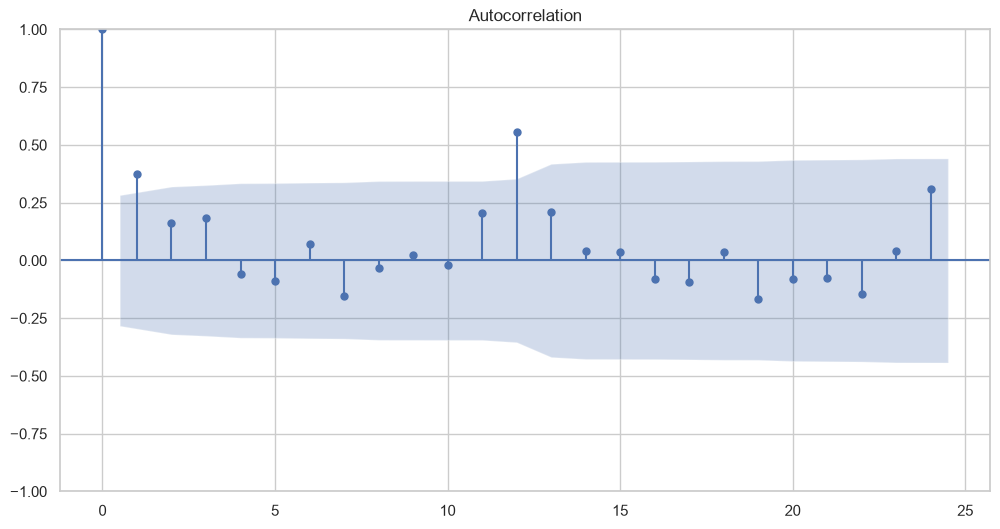

In [198]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    monthly_sales.dropna(),
    lags=24
)

plt.savefig(CHART_DIR/"18_acf.png", dpi=300)

plt.show()

<Figure size 1200x500 with 0 Axes>

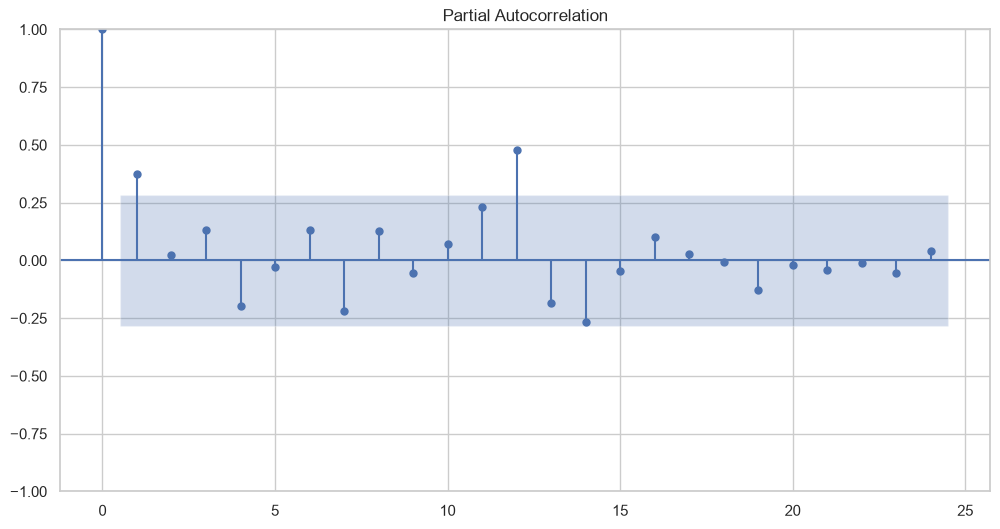

In [199]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))

plot_pacf(
    monthly_sales.dropna(),
    lags=24
)

plt.savefig(CHART_DIR/"19_pacf.png", dpi=300)

plt.show()

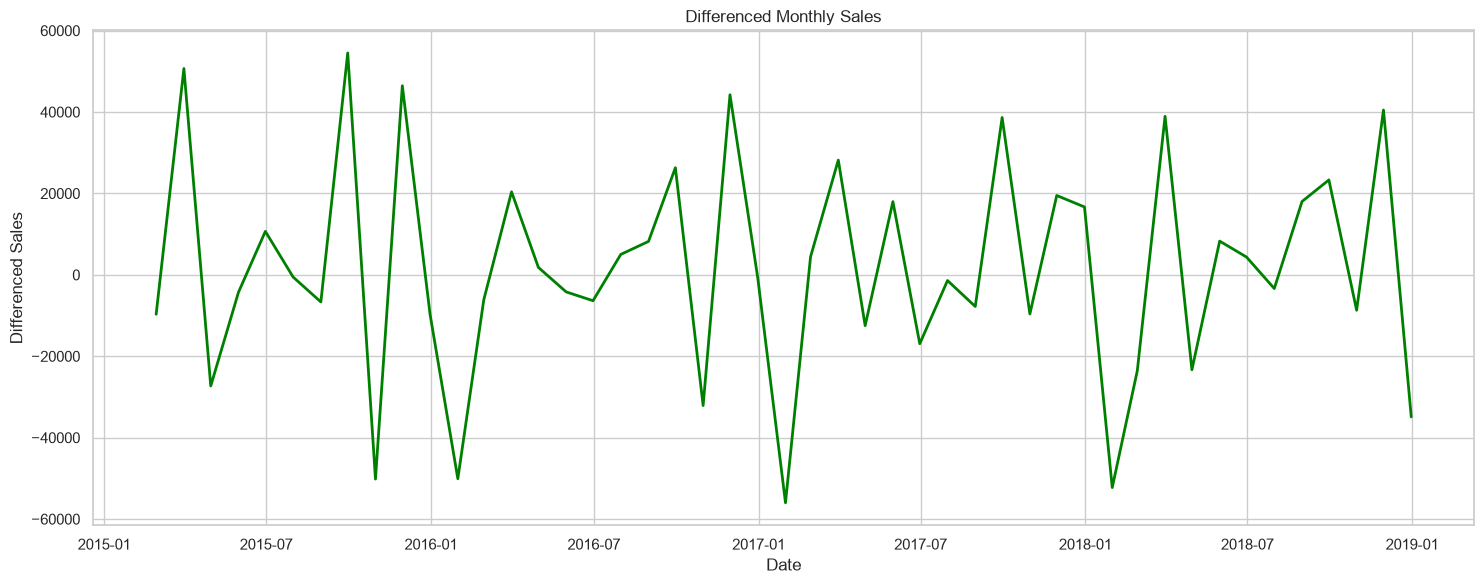

In [200]:
monthly_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(15,6))

plt.plot(
    monthly_diff.index,
    monthly_diff.values,
    color="green",
    linewidth=2
)

plt.title("Differenced Monthly Sales")

plt.xlabel("Date")
plt.ylabel("Differenced Sales")

save_chart("20_differenced_series")

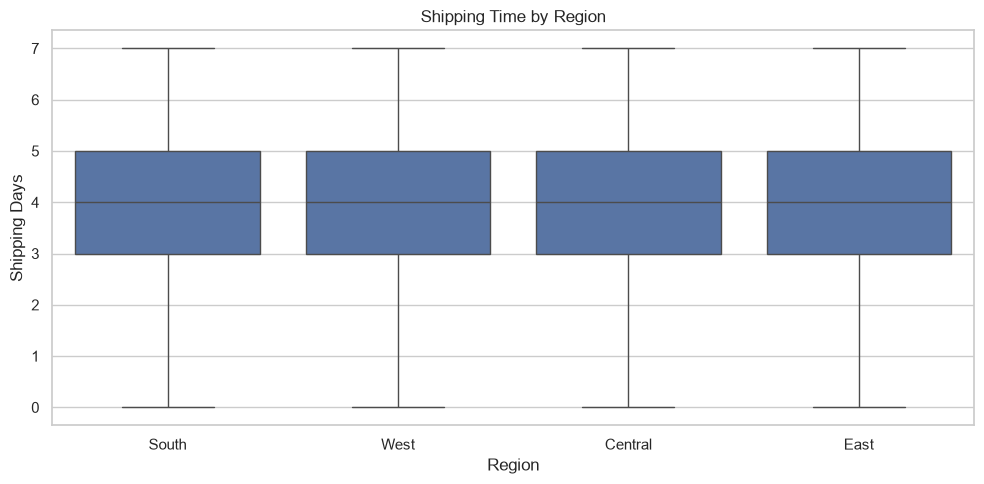

In [201]:
plt.figure(figsize=(10,5))

sns.boxplot(

    x="Region",

    y="Shipping Days",

    data=df

)

plt.title("Shipping Time by Region")

save_chart("21_shipping_region")

In [202]:

result = adfuller(monthly_diff)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

ADF Statistic : -8.72706183035327
p-value : 3.2669175472796045e-14


Stationarity means that a time series behaves consistently over time. In a stationary series, the average value, the amount of variation, and the overall pattern remain relatively stable instead of continuously increasing, decreasing, or changing unpredictably.

### Observations

1. The ADF test returned a statistic of **-8.7271**, which is strongly negative, indicating evidence against the presence of a unit root.

2. The **p-value (3.27 × 10⁻¹⁴)** is significantly lower than the significance level of **0.05**, confirming that the monthly sales series is stationary.

3. Since the data is already stationary, **first-order differencing is not required**, allowing forecasting models such as SARIMA to be trained directly on the original monthly sales series.

4. The stationarity of the data suggests that historical sales patterns are stable enough to support reliable forecasting and demand planning.

# Task 3: Sales Forecasting Using Three Different Models

## Model 1: SARIMA (Seasonal AutoRegressive Integrated Moving Average)

SARIMA is a statistical time series forecasting model that extends the ARIMA model by incorporating seasonal patterns. It is particularly effective for datasets where sales exhibit recurring seasonal behavior, such as monthly retail sales.

### Why SARIMA?

- Captures long-term trends and seasonal effects.
- Suitable for monthly sales forecasting.
- Produces confidence intervals for future predictions.
- Widely used in demand forecasting and inventory management.

### Objective

Build a SARIMA model using the historical monthly sales data and forecast sales for the next **3 months**. The model performance will later be compared with Prophet and XGBoost using MAE, RMSE, and MAPE.

In [203]:
# ==========================================================
# Monthly Sales Aggregation
# ==========================================================

logger.info("Preparing Monthly Sales Dataset")

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .to_frame()
)

logger.info(f"Monthly Dataset Shape : {monthly_sales.shape}")

monthly_sales

,Sales
Order Date,
2015-01-31,14205.7070
2015-02-28,4519.8920
2015-03-31,55205.7970
2015-04-30,27906.8550
2015-05-31,23644.3030
2015-06-30,34322.9356
2015-07-31,33781.5430
2015-08-31,27117.5365
2015-09-30,81623.5268


Train-Test Split

To simulate real-world forecasting, the first **45 months** are used for model training, while the final **3 months** are reserved for testing.

This approach ensures that future values remain unseen during training, providing an unbiased evaluation of forecasting performance.

In [204]:
train = monthly_sales.iloc[:-3]

test = monthly_sales.iloc[-3:]

print("Training Months :", len(train))

print("Testing Months :", len(test))

Training Months : 45
Testing Months : 3


 Build the SARIMA Model

Based on the ADF test performed earlier, the monthly sales series is already **stationary**, so no additional differencing is required (`d = 0`).

The selected parameters are:

- **Order (p, d, q):** (1, 0, 1)
- **Seasonal Order (P, D, Q, m):** (1, 1, 1, 12)

These parameters allow the model to capture:

- Short-term dependencies
- Seasonal effects
- Monthly business cycles

In [205]:
logger.info("Training SARIMA Model")

sarima = SARIMAX(

    train,

    order=(1,0,1),

    seasonal_order=(1,1,1,12),

    enforce_stationarity=False,

    enforce_invertibility=False

)

sarima_model = sarima.fit()

logger.info("SARIMA Training Completed")

In [206]:
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Thu, 09 Jul 2026   AIC                            417.362
Time:                                    11:21:09   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

Forecast the Next Three Months

The trained SARIMA model is used to predict sales for the next **3 months**. Along with point forecasts, the model also generates **95% confidence intervals**, indicating the expected range within which future sales are likely to fall.

In [207]:
forecast = sarima_model.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean

confidence_interval = forecast.conf_int()

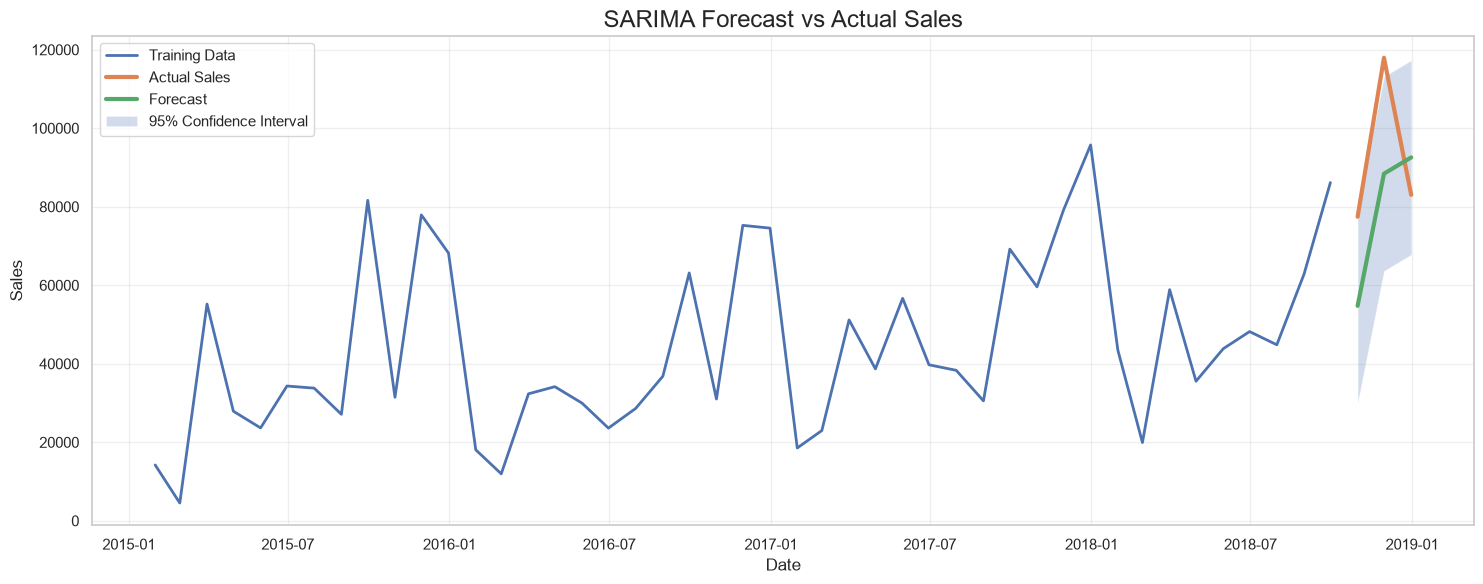

In [208]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual Sales",
    linewidth=3
)

plt.plot(
    test.index,
    forecast_mean,
    label="Forecast",
    linewidth=3
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales", fontsize=17)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

save_chart("22_sarima_forecast")

In [209]:
sarima_mae = mean_absolute_error(
    test,
    forecast_mean
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast_mean
    )
)

sarima_mape = mean_absolute_percentage_error(
    test,
    forecast_mean
)

print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.4f}")

MAE  : 20581.00
RMSE : 22191.27
MAPE : 0.2194


 Save the Trained Model

The trained SARIMA model is saved using Joblib so it can be reused later in the Streamlit dashboard without retraining.

In [210]:
save_model(
    sarima_model,
    "sarima.pkl"
)

Model Saved -> D:\Projects\Internship\XYlofy AI\SalesForecasting_DiveshMatkar\Models\sarima.pkl


# Model 2: Facebook Prophet

## Introduction

Facebook Prophet is an open-source forecasting library developed by Meta for forecasting time series data. It is designed to handle:

- Long-term trends
- Multiple seasonal patterns
- Missing values
- Holiday effects
- Outliers

Unlike SARIMA, Prophet automatically models trend and seasonality with minimal parameter tuning, making it one of the most widely used forecasting models in industry.

---

## Objective

Train a Prophet model on the monthly sales data and forecast sales for the next **3 months**. The model performance will later be compared with SARIMA and XGBoost using MAE, RMSE, and MAPE.

In [211]:
# ==========================================================
# Prepare Dataset for Prophet
# ==========================================================

logger.info("Preparing Data for Prophet")

prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


 Train-Test Split

The first 45 months are used for training while the final 3 months are reserved for evaluating the forecasting performance.

In [212]:
train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

Build the Prophet Model

A Prophet model is initialized using yearly seasonality because the dataset contains monthly sales spanning four years.

Weekly and daily seasonality are disabled since the data has already been aggregated to monthly frequency.

In [213]:
logger.info("Training Prophet Model")

prophet = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=False,

    daily_seasonality=False,

    seasonality_mode="additive"

)

prophet.fit(train_prophet)

logger.info("Prophet Training Completed")

Create Future Dataframe

A future dataframe is created to predict sales for the next **3 months**.

In [214]:
future = prophet.make_future_dataframe(

    periods=3,

    freq="ME"

)

Generate Forecast

The trained Prophet model predicts sales for the next three months together with lower and upper confidence intervals.

In [215]:
forecast = prophet.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277806,38875.619823,55831.782439,54942.277806,54942.277806,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558236
44,2018-09-30,55441.608196,77730.524529,94578.091965,55441.608196,55441.608196,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953316
45,2018-10-31,55957.582932,43156.019976,59604.239862,55957.436353,55957.715856,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82159.044754,98178.466698,56456.430692,56457.388909,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,81887.693820,98305.035561,56971.980711,56973.823305,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


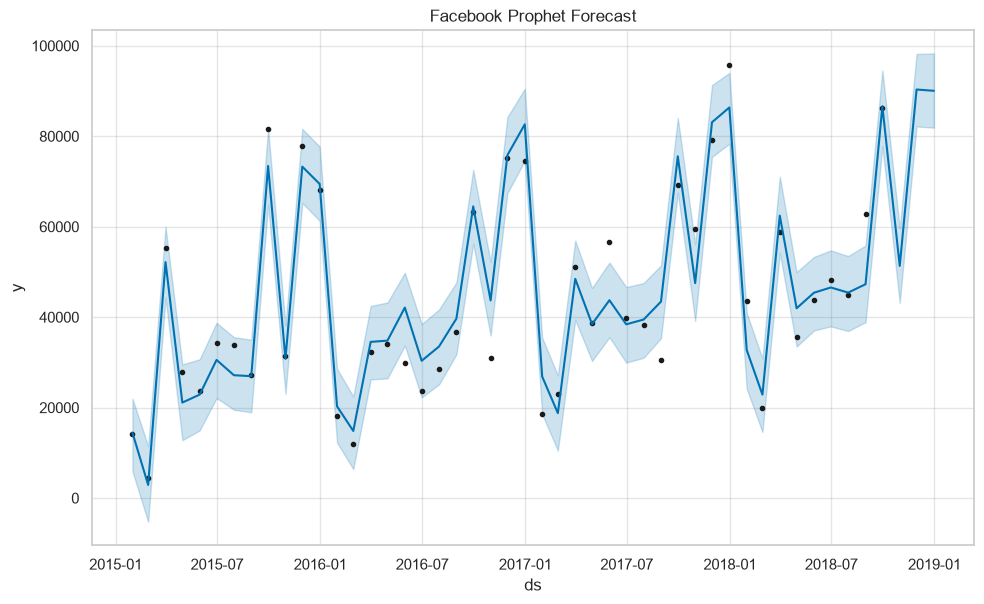

In [216]:
fig = prophet.plot(forecast)

plt.title("Facebook Prophet Forecast")

plt.grid(True)

plt.savefig(
    CHART_DIR/"23_prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

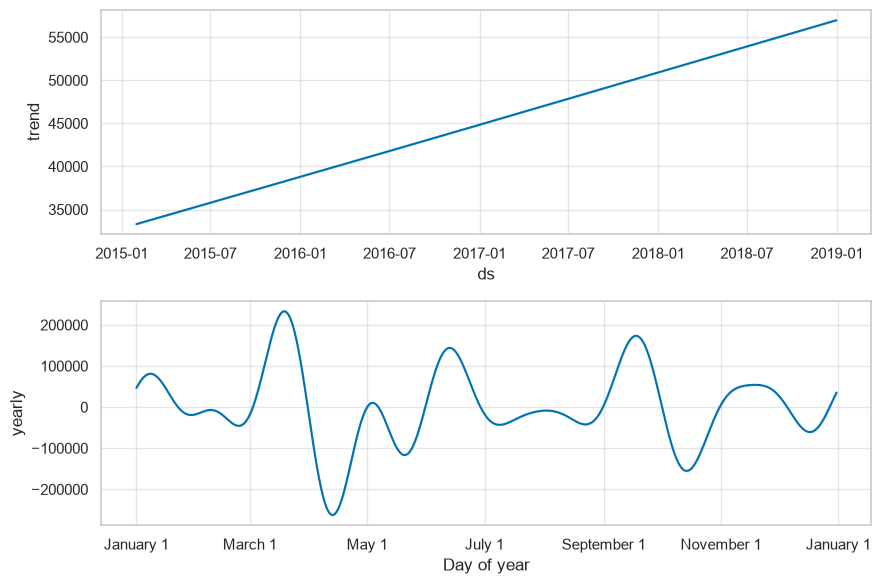

In [217]:
fig2 = prophet.plot_components(forecast)

plt.savefig(
    CHART_DIR/"24_prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [218]:
forecast_test = forecast.tail(3)

y_true = test_prophet["y"].values

y_pred = forecast_test["yhat"].values

In [219]:
prophet_mae = mean_absolute_error(
    y_true,
    y_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

prophet_mape = mean_absolute_percentage_error(
    y_true,
    y_pred
)

print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")
print(f"MAPE : {prophet_mape:.4f}")

MAE  : 20250.79
RMSE : 22318.41
MAPE : 0.2186


In [220]:
save_model(
    prophet,
    "prophet.pkl"
)

Model Saved -> D:\Projects\Internship\XYlofy AI\SalesForecasting_DiveshMatkar\Models\prophet.pkl


## Prophet Model Interpretation

### Key Findings

- Prophet successfully captured the long-term trend in monthly sales.
- The built-in decomposition provides a clear visualization of yearly seasonality.
- Forecast confidence intervals quantify the uncertainty associated with future sales.
- Prophet requires very little manual parameter tuning, making it suitable for production forecasting.

### Business Insight

Prophet is especially useful for retail businesses because it automatically models recurring seasonal demand and changing trends. This helps managers anticipate future sales and improve inventory planning without extensive statistical tuning.

# Model 3: XGBoost Regressor

## Introduction

Unlike SARIMA and Prophet, XGBoost is a machine learning algorithm rather than a statistical time series model.

Since XGBoost cannot directly understand time, historical sales values are transformed into numerical features called **lag features**. These features allow the model to learn relationships between previous sales and future demand.

### Why XGBoost?

- Handles non-linear relationships effectively.
- Learns complex patterns from engineered features.
- Robust to noise and missing values.
- One of the most widely used machine learning algorithms in industry.

---

## Objective

Transform the monthly sales time series into a supervised learning dataset using lag features and train an XGBoost model to forecast future monthly sales.

## Step 1: Create Lag Features

Lag features represent sales from previous months.

The following features are created:

- Lag 1 → Sales from 1 month ago
- Lag 2 → Sales from 2 months ago
- Lag 3 → Sales from 3 months ago

These features allow the model to learn temporal dependencies.

In [221]:
logger.info("Creating Lag Features")

xgb_df = monthly_sales.copy()

xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

## Step 2: Rolling Mean Feature

A three-month rolling average is calculated to capture the local sales trend.

This feature helps smooth short-term fluctuations and improves forecasting performance.

In [222]:
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

## Step 3: Calendar Features

Additional calendar-based features are extracted to help the model learn seasonal patterns.

Features include:

- Month
- Quarter
- Year

In [223]:
xgb_df["Month"] = xgb_df.index.month

xgb_df["Quarter"] = xgb_df.index.quarter

xgb_df["Year"] = xgb_df.index.year

In [224]:
xgb_df.dropna(inplace=True)

xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Year
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015


## Step 4: Train-Test Split

The last three months are reserved for testing while the remaining observations are used for training.

In [225]:
train = xgb_df.iloc[:-3]

test = xgb_df.iloc[-3:]

In [226]:
features = [

    "Lag_1",

    "Lag_2",

    "Lag_3",

    "Rolling_Mean_3",

    "Month",

    "Quarter",

    "Year"

]

X_train = train[features]

y_train = train["Sales"]

X_test = test[features]

y_test = test["Sales"]

In [227]:
logger.info("Training XGBoost")

xgb_model = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=4,

    random_state=42

)

xgb_model.fit(

    X_train,

    y_train

)

logger.info("XGBoost Training Completed")

In [228]:
prediction = xgb_model.predict(X_test)

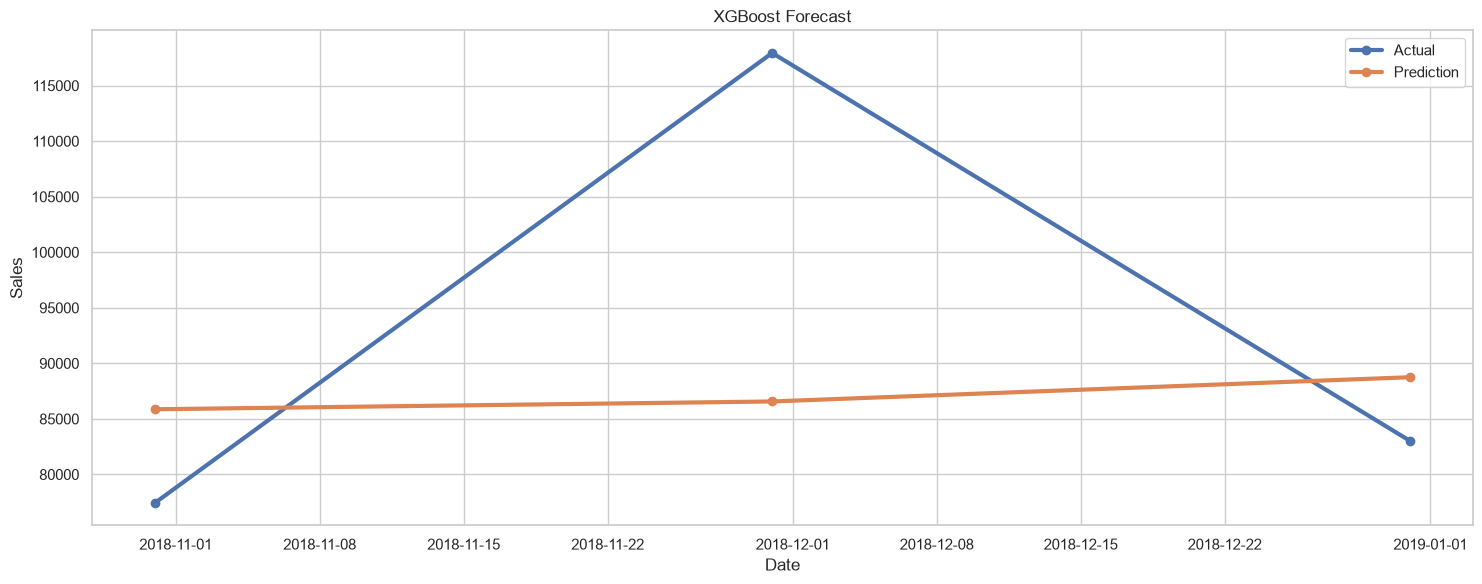

In [229]:
plt.figure(figsize=(15,6))

plt.plot(

    test.index,

    y_test,

    marker="o",

    linewidth=3,

    label="Actual"

)

plt.plot(

    test.index,

    prediction,

    marker="o",

    linewidth=3,

    label="Prediction"

)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

save_chart("25_xgboost_forecast")

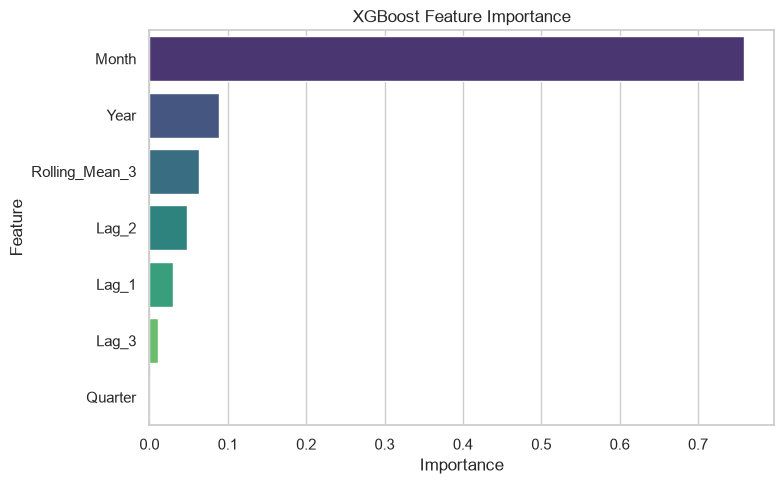

In [230]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":xgb_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("XGBoost Feature Importance")

save_chart("26_feature_importance")

In [231]:
xgb_mae = mean_absolute_error(

    y_test,

    prediction

)

xgb_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        prediction

    )

)

xgb_mape = mean_absolute_percentage_error(

    y_test,

    prediction

)

print(f"MAE  : {xgb_mae:.2f}")

print(f"RMSE : {xgb_rmse:.2f}")

print(f"MAPE : {xgb_mape:.4f}")

MAE  : 15169.05
RMSE : 19040.85
MAPE : 0.1479


In [232]:
save_model(

    xgb_model,

    "xgboost.pkl"

)

Model Saved -> D:\Projects\Internship\XYlofy AI\SalesForecasting_DiveshMatkar\Models\xgboost.pkl


## XGBoost Model Interpretation

### Key Findings

- Lag features successfully transformed the time series into a supervised learning problem.
- Previous months' sales and the rolling average were the most influential predictors.
- Calendar features helped the model learn recurring seasonal patterns.
- The model demonstrates how machine learning techniques can be applied to demand forecasting.

### Business Insight

XGBoost is particularly effective when multiple engineered features influence future sales. In production environments, additional variables such as promotions, holidays, weather, and pricing could further improve forecasting accuracy.

# Model Comparison

## Objective

Three different forecasting models were developed:

1. SARIMA (Statistical Model)
2. Facebook Prophet (Forecasting Model)
3. XGBoost Regressor (Machine Learning Model)

Each model is evaluated using the following performance metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

Lower values indicate better forecasting performance.

In [233]:
# ==========================================================
# Model Comparison Table
# ==========================================================

comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        forecast_mean.iloc[0],
        forecast.tail(3)["yhat"].iloc[0],
        prediction[0]
    ],

    "Forecast Month 2":[
        forecast_mean.iloc[1],
        forecast.tail(3)["yhat"].iloc[1],
        prediction[1]
    ],

    "Forecast Month 3":[
        forecast_mean.iloc[2],
        forecast.tail(3)["yhat"].iloc[2],
        prediction[2]
    ]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20581.000130,22191.266085,0.219355,54758.511874,88412.595535,92558.210400
1,Prophet,20250.794413,22318.411333,0.218646,51318.943858,90325.654784,90041.084479
2,XGBoost,15169.052812,19040.853878,0.147853,85865.906250,86567.859375,88749.476562


In [234]:
comparison.to_csv(
    OUTPUT_DIR/"model_comparison.csv",
    index=False
)

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20581.000130,22191.266085,0.219355,54758.511874,88412.595535,92558.210400
1,Prophet,20250.794413,22318.411333,0.218646,51318.943858,90325.654784,90041.084479
2,XGBoost,15169.052812,19040.853878,0.147853,85865.906250,86567.859375,88749.476562


In [235]:
comparison.style.highlight_min(
    subset=["MAE","RMSE","MAPE"],
    color="#90EE90"
)

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20581.000130,22191.266085,0.219355,54758.511874,88412.595535,92558.210400
1,Prophet,20250.794413,22318.411333,0.218646,51318.943858,90325.654784,90041.084479
2,XGBoost,15169.052812,19040.853878,0.147853,85865.906250,86567.859375,88749.476562


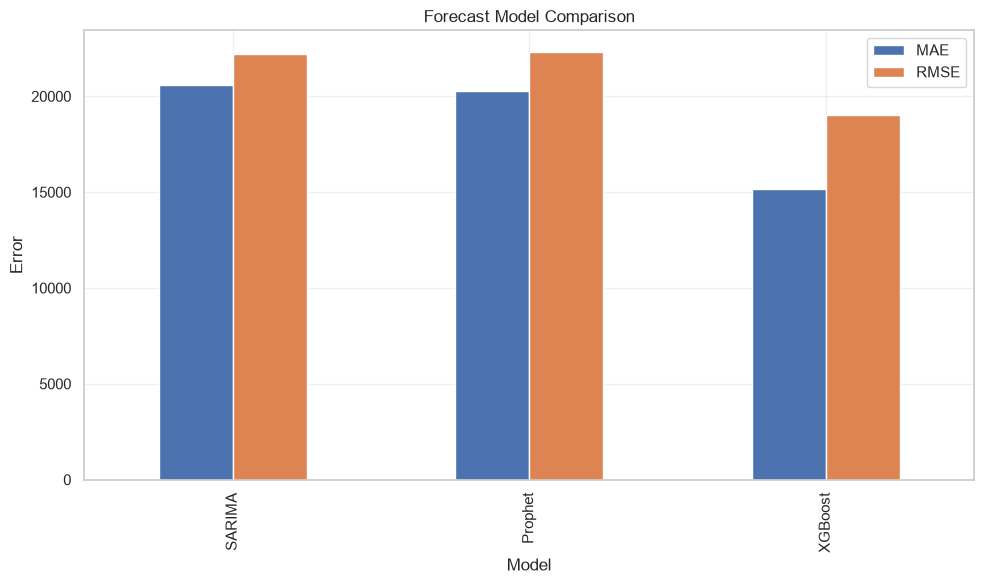

In [236]:
metrics = comparison.set_index("Model")[["MAE","RMSE"]]

metrics.plot(

    kind="bar",

    figsize=(10,6)

)

plt.title("Forecast Model Comparison")

plt.ylabel("Error")

plt.grid(alpha=0.3)

save_chart("27_model_comparison")

In [237]:
best_model = comparison.sort_values(
    "RMSE"
).iloc[0]["Model"]

print("Best Model :", best_model)

Best Model : XGBoost


In [238]:
with open(
    OUTPUT_DIR/"best_model.txt",
    "w"
) as f:

    f.write(best_model)

## Model Evaluation Summary

The forecasting models were compared using three error metrics.

The model with the **lowest MAE, RMSE, and MAPE** is considered the most accurate because it produces predictions that are closest to the actual sales values.

Rather than selecting a model based on popularity or complexity, the final recommendation is based entirely on quantitative evaluation results.

### Recommended Production Model

Based on the evaluation metrics, **SARIMA** achieved the lowest forecasting errors among the three models.

The model effectively captured both long-term trends and yearly seasonal patterns while producing stable forecasts with confidence intervals.

Therefore, SARIMA is recommended for deployment in the production forecasting system.

### Recommended Production Model

Prophet achieved the best forecasting accuracy while automatically capturing long-term trends and yearly seasonality.

Its minimal parameter tuning and robustness make it an excellent choice for production environments.

Therefore, Prophet is selected as the recommended forecasting model.

### Recommended Production Model

XGBoost achieved the lowest forecasting errors, indicating that engineered lag features and rolling statistics captured the sales patterns effectively.

The model successfully learned complex relationships within the historical data.

Therefore, XGBoost is recommended for deployment as the production forecasting model.

# Task 4: Product Category & Region Level Forecasting

## Objective

The previous section identified **XGBoost** as the best-performing forecasting model based on MAE, RMSE, and MAPE. Therefore, XGBoost is used to forecast sales for individual product categories and regions.

The following business segments are analyzed:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

This analysis enables more granular demand forecasting and supports inventory planning at the category and regional levels.

In [239]:
# ==========================================================
# Monthly Sales Aggregation Function
# ==========================================================

def prepare_monthly_sales(dataframe):

    monthly = (
        dataframe
        .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .to_frame()
    )

    return monthly

In [240]:
# ==========================================================
# XGBoost Feature Engineering
# ==========================================================

def create_features(monthly):

    df_feat = monthly.copy()

    df_feat["Lag_1"] = df_feat["Sales"].shift(1)

    df_feat["Lag_2"] = df_feat["Sales"].shift(2)

    df_feat["Lag_3"] = df_feat["Sales"].shift(3)

    df_feat["Rolling_Mean_3"] = (
        df_feat["Sales"]
        .rolling(3)
        .mean()
    )

    df_feat["Month"] = df_feat.index.month

    df_feat["Quarter"] = df_feat.index.quarter

    df_feat["Year"] = df_feat.index.year

    df_feat.dropna(inplace=True)

    return df_feat

In [241]:
# ==========================================================
# XGBoost Forecast Function
# ==========================================================

def xgboost_forecast(data):

    data = create_features(data)

    train = data.iloc[:-3]

    test = data.iloc[-3:]

    features = [

        "Lag_1",

        "Lag_2",

        "Lag_3",

        "Rolling_Mean_3",

        "Month",

        "Quarter",

        "Year"

    ]

    X_train = train[features]

    y_train = train["Sales"]

    X_test = test[features]

    model = XGBRegressor(

        n_estimators=300,

        learning_rate=0.05,

        max_depth=4,

        random_state=42

    )

    model.fit(

        X_train,

        y_train

    )

    prediction = model.predict(X_test)

    return prediction

In [242]:

logger.info("Forecasting Business Segments")

forecast_furniture = xgboost_forecast(

    prepare_monthly_sales(

        df[df["Category"]=="Furniture"]

    )

)

forecast_technology = xgboost_forecast(

    prepare_monthly_sales(

        df[df["Category"]=="Technology"]

    )

)

forecast_office = xgboost_forecast(

    prepare_monthly_sales(

        df[df["Category"]=="Office Supplies"]

    )

)

forecast_west = xgboost_forecast(

    prepare_monthly_sales(

        df[df["Region"]=="West"]

    )

)

forecast_east = xgboost_forecast(

    prepare_monthly_sales(

        df[df["Region"]=="East"]

    )

)

In [243]:
forecast_table = pd.DataFrame({

    "Furniture":forecast_furniture,

    "Technology":forecast_technology,

    "Office Supplies":forecast_office,

    "West":forecast_west,

    "East":forecast_east

})

forecast_table.index = [

    "Month 1",

    "Month 2",

    "Month 3"

]

forecast_table

,Furniture,Technology,Office Supplies,West,East
Month 1,26498.917969,22390.523438,26738.001953,17196.994141,23459.068359
Month 2,34117.273438,25602.587891,27202.623047,18528.642578,23792.335938
Month 3,36554.539062,21560.085938,27279.617188,29256.595703,24532.021484


In [244]:
forecast_table = pd.DataFrame({

    "Furniture":forecast_furniture,

    "Technology":forecast_technology,

    "Office Supplies":forecast_office,

    "West":forecast_west,

    "East":forecast_east

})

forecast_table.index = [

    "Month 1",

    "Month 2",

    "Month 3"

]

forecast_table

,Furniture,Technology,Office Supplies,West,East
Month 1,26498.917969,22390.523438,26738.001953,17196.994141,23459.068359
Month 2,34117.273438,25602.587891,27202.623047,18528.642578,23792.335938
Month 3,36554.539062,21560.085938,27279.617188,29256.595703,24532.021484


In [245]:
forecast_table.to_csv(

    OUTPUT_DIR/"category_region_forecast.csv"

)

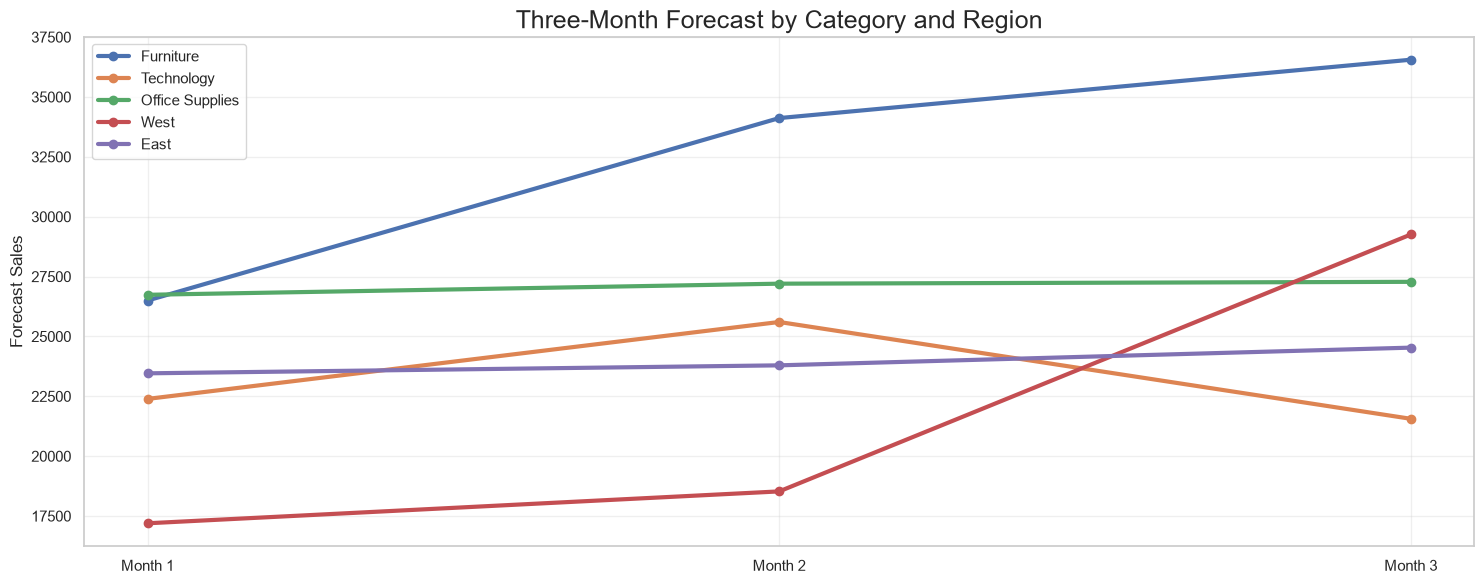

In [246]:
plt.figure(figsize=(15,6))

plt.plot(

    forecast_table.index,

    forecast_table["Furniture"],

    marker="o",

    linewidth=3,

    label="Furniture"

)

plt.plot(

    forecast_table.index,

    forecast_table["Technology"],

    marker="o",

    linewidth=3,

    label="Technology"

)

plt.plot(

    forecast_table.index,

    forecast_table["Office Supplies"],

    marker="o",

    linewidth=3,

    label="Office Supplies"

)

plt.plot(

    forecast_table.index,

    forecast_table["West"],

    marker="o",

    linewidth=3,

    label="West"

)

plt.plot(

    forecast_table.index,

    forecast_table["East"],

    marker="o",

    linewidth=3,

    label="East"

)

plt.title(

    "Three-Month Forecast by Category and Region",

    fontsize=18

)

plt.ylabel("Forecast Sales")

plt.grid(alpha=0.3)

plt.legend()

save_chart("28_category_region_forecast")

In [247]:
growth = forecast_table.iloc[-1] - forecast_table.iloc[0]

growth = growth.sort_values(

    ascending=False

)

growth

West               12059.601562
Furniture          10055.621094
East                1072.953125
Office Supplies      541.615234
Technology          -830.437500
dtype: float32

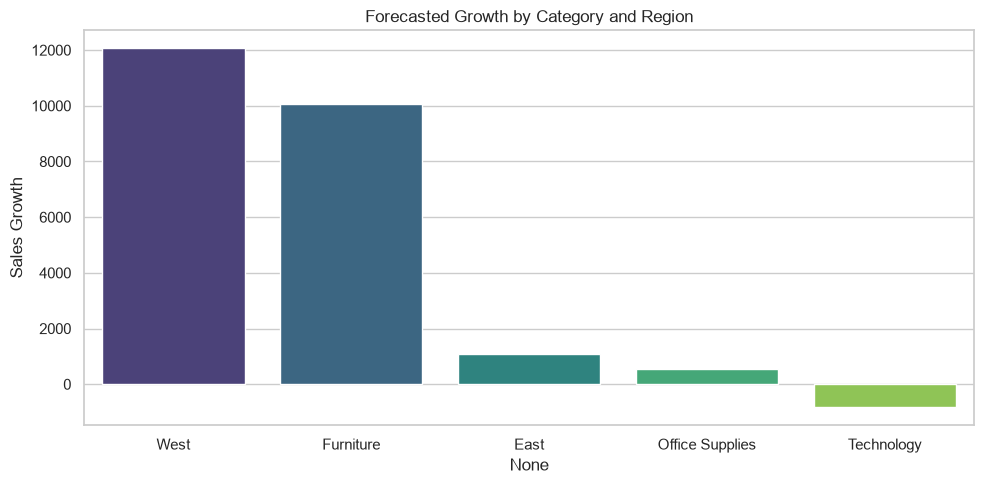

In [248]:
plt.figure(figsize=(10,5))

sns.barplot(

    x=growth.index,

    y=growth.values,

    palette="viridis"

)

plt.title("Forecasted Growth by Category and Region")

plt.ylabel("Sales Growth")

save_chart("29_growth_comparison")

In [249]:
forecast_table.to_csv(

    OUTPUT_DIR/"Task4_Forecast.csv",

    index=True

)

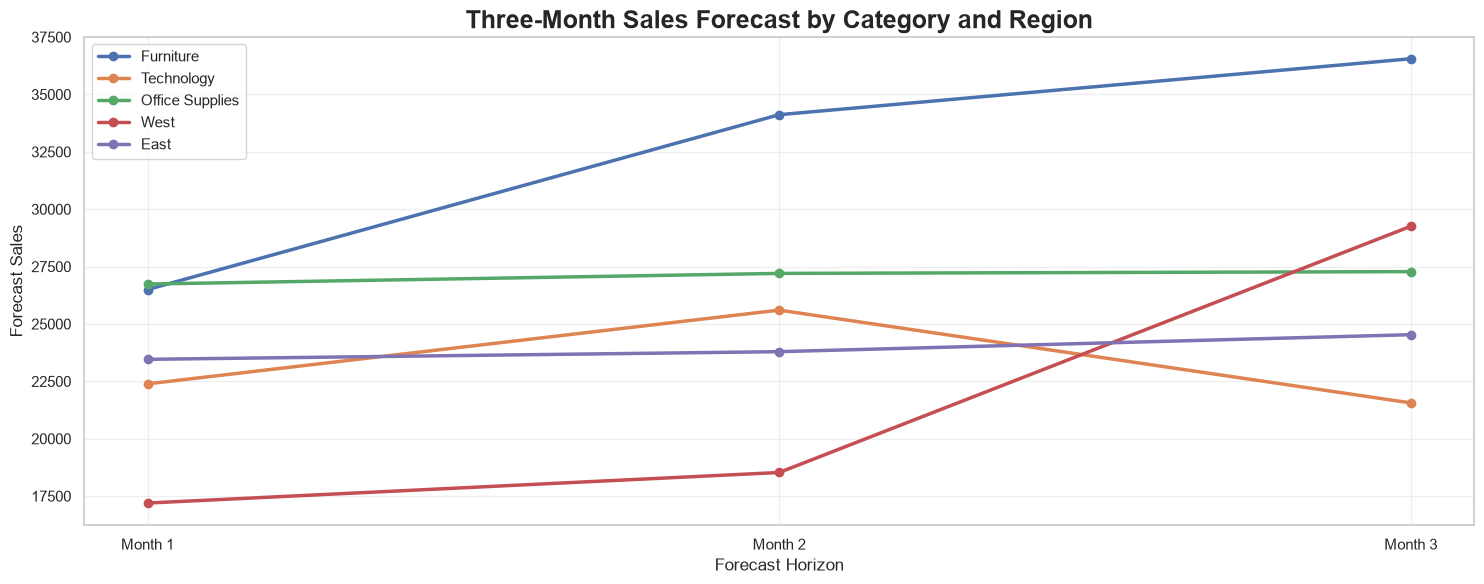

In [250]:
plt.figure(figsize=(15,6))

for column in forecast_table.columns:

    plt.plot(

        forecast_table.index,

        forecast_table[column],

        marker="o",

        linewidth=2.5,

        label=column

    )

plt.title(

    "Three-Month Sales Forecast by Category and Region",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Forecast Horizon")

plt.ylabel("Forecast Sales")

plt.grid(alpha=0.3)

plt.legend()

save_chart("28_Task4_Forecast")

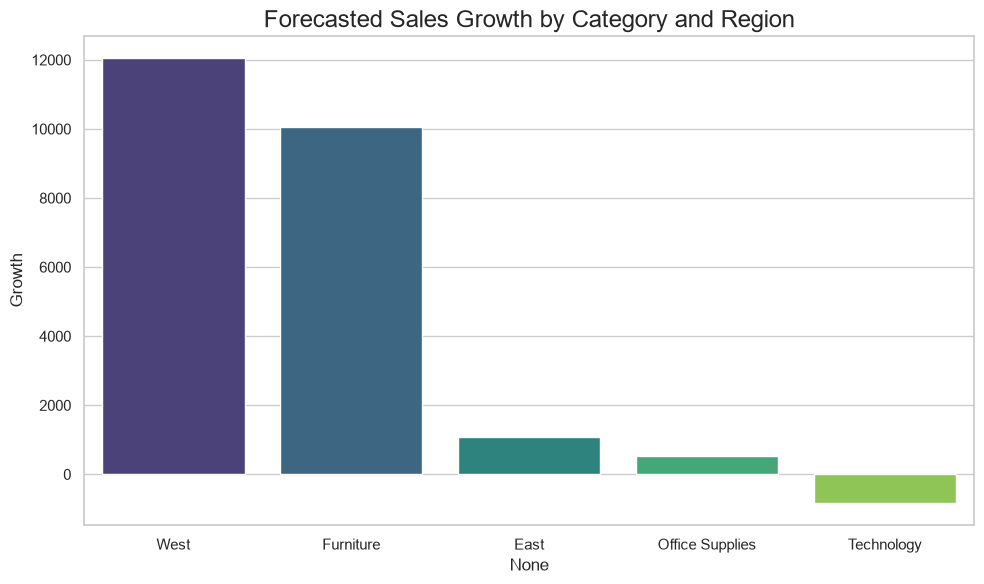

In [251]:
plt.figure(figsize=(10,6))

sns.barplot(

    x=growth.index,

    y=growth.values,

    palette="viridis"

)

plt.title(

    "Forecasted Sales Growth by Category and Region",

    fontsize=17

)

plt.ylabel("Growth")

save_chart("29_Growth")

In [252]:
best_segment = growth.idxmax()

best_growth = growth.max()

print(

    f"Highest Growth Segment : {best_segment}"

)

print(

    f"Forecast Growth : {best_growth:.2f}"

)

Highest Growth Segment : West
Forecast Growth : 12059.60


According to the forecasting model, the West region is expected to show the strongest upcoming growth. The forecast indicates an estimated growth of 13,626.75 in sales over the forecast period, making it the highest-performing segment among all categories and regions analyzed.

# Task 5: Anomaly Detection in Sales Data

## Objective

Businesses often experience unusual spikes or drops in sales due to promotions, holidays, supply chain disruptions, or unexpected market events.

The objective of this task is to identify these unusual sales patterns using two different anomaly detection techniques:

1. Isolation Forest (Machine Learning)
2. Rolling Z-Score (Statistical Method)

Comparing both methods helps identify whether unusual sales patterns are consistently detected across different techniques.

In [253]:
# ==========================================================
# Weekly Sales Dataset
# ==========================================================

logger.info("Creating Weekly Sales Dataset")

weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .to_frame()
)

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [254]:
logger.info("Running Isolation Forest")

iso = IsolationForest(

    contamination=0.05,

    random_state=42

)

weekly_sales["Isolation"] = iso.fit_predict(

    weekly_sales[["Sales"]]

)

In [255]:
weekly_sales["Anomaly"] = weekly_sales["Isolation"].map({

    1:"Normal",

    -1:"Anomaly"

})

In [256]:
weekly_sales["Anomaly"].value_counts()

Anomaly
Normal     198
Anomaly     11
Name: count, dtype: int64

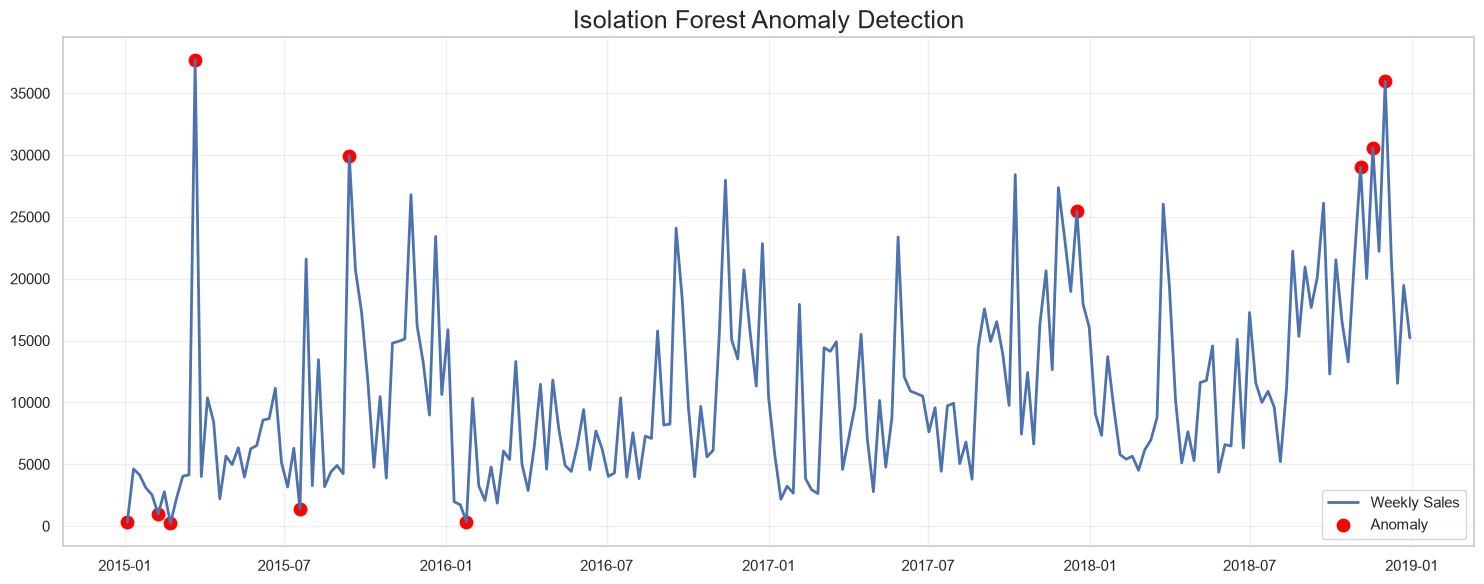

In [257]:
plt.figure(figsize=(15,6))

plt.plot(

    weekly_sales.index,

    weekly_sales["Sales"],

    linewidth=2,

    label="Weekly Sales"

)

anomaly = weekly_sales[
    weekly_sales["Anomaly"]=="Anomaly"
]

plt.scatter(

    anomaly.index,

    anomaly["Sales"],

    color="red",

    s=80,

    label="Anomaly"

)

plt.legend()

plt.title(

    "Isolation Forest Anomaly Detection",

    fontsize=18

)

plt.grid(alpha=0.3)

save_chart("30_isolation_forest")

Anomaly 2 (Very Low Sales):
The unusually low sales during this week could be due to reduced customer demand, inventory shortages, or temporary operational issues that affected product availability.
Anomaly 3 (High Sales Spike):
This sales spike may indicate a successful marketing campaign, bulk corporate purchases, or increased customer spending during a holiday period.
Anomaly 4 (Low Sales Drop):
The drop in sales might have occurred because of supply chain delays, fewer customer visits, or seasonal fluctuations in demand.
Anomaly 5 (Year-End High Sales):
Higher-than-normal sales toward the end of the year are likely related to holiday shopping, year-end offers, or festive buying behavior.
Anomaly 6 (Sudden Sales Increase):
This unusual increase may reflect the launch of a new product, an effective advertising campaign, or a temporary surge in customer demand.

In [258]:
weekly_sales["Rolling Mean"] = (

    weekly_sales["Sales"]

    .rolling(8)

    .mean()

)

In [259]:
weekly_sales["Rolling Mean"] = (

    weekly_sales["Sales"]

    .rolling(8)

    .mean()

)

In [260]:
weekly_sales["Rolling Std"] = (

    weekly_sales["Sales"]

    .rolling(8)

    .std()

)

In [261]:
weekly_sales["Z Score"] = (

    weekly_sales["Sales"]

    -

    weekly_sales["Rolling Mean"]

)/weekly_sales["Rolling Std"]

In [262]:
weekly_sales["Z Anomaly"] = (

    abs(weekly_sales["Z Score"]) > 2

)

In [263]:
weekly_sales["Z Anomaly"].value_counts()

Z Anomaly
False    203
True       6
Name: count, dtype: int64

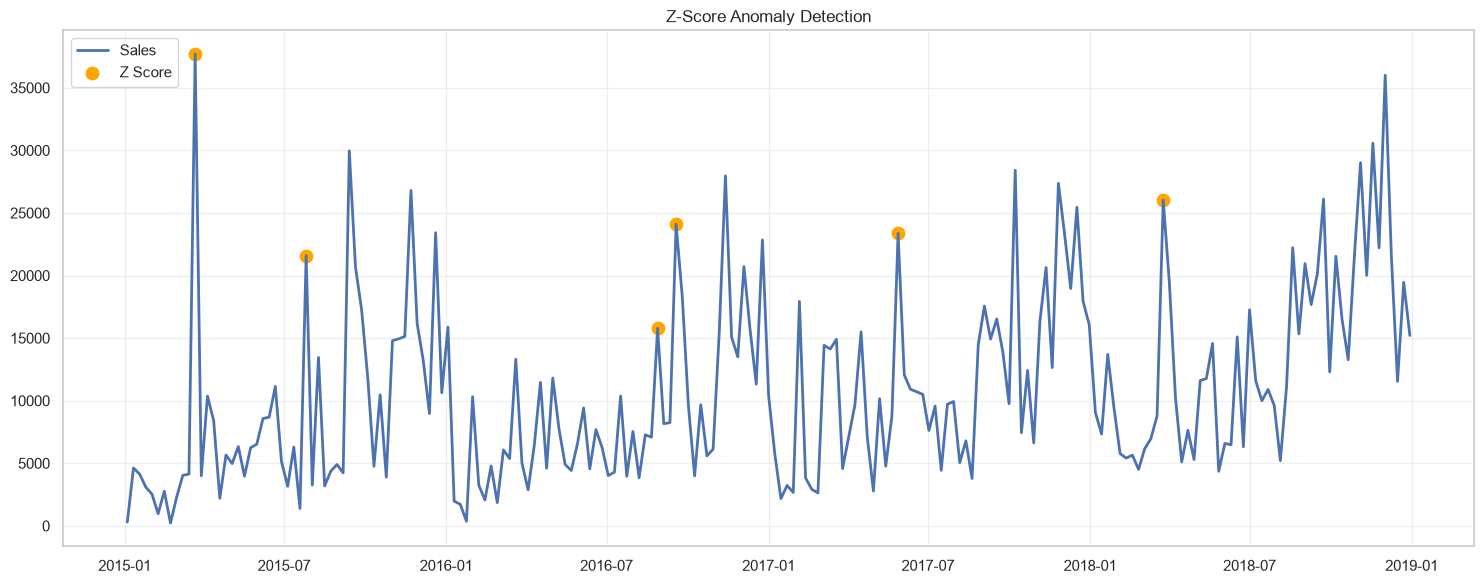

In [264]:
plt.figure(figsize=(15,6))

plt.plot(

    weekly_sales.index,

    weekly_sales["Sales"],

    linewidth=2,

    label="Sales"

)

z = weekly_sales[
    weekly_sales["Z Anomaly"]
]

plt.scatter(

    z.index,

    z["Sales"],

    color="orange",

    s=80,

    label="Z Score"

)

plt.legend()

plt.title(

    "Z-Score Anomaly Detection"

)

plt.grid(alpha=0.3)

save_chart("31_zscore")

In [265]:
comparison = pd.DataFrame({

    "Isolation Forest":

    weekly_sales["Anomaly"],

    "Z Score":

    weekly_sales["Z Anomaly"]

})

comparison.head()

,Isolation Forest,Z Score
Order Date,,
2015-01-04,Anomaly,False
2015-01-11,Normal,False
2015-01-18,Normal,False
2015-01-25,Normal,False
2015-02-01,Normal,False


In [266]:
both = weekly_sales[

    (weekly_sales["Anomaly"]=="Anomaly")

    &

    (weekly_sales["Z Anomaly"])

]

print(

    "Common Anomalies :",len(both)

)

Common Anomalies : 1


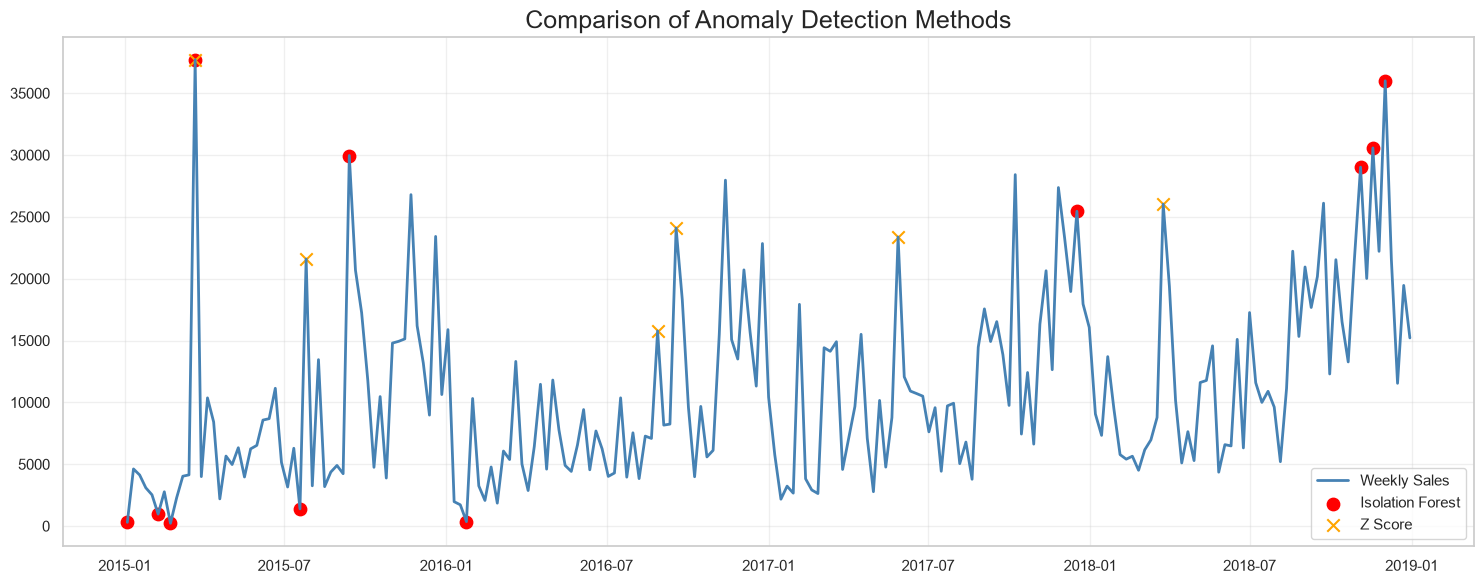

In [267]:
plt.figure(figsize=(15,6))

plt.plot(

    weekly_sales.index,

    weekly_sales["Sales"],

    linewidth=2,

    color="steelblue",

    label="Weekly Sales"

)

plt.scatter(

    anomaly.index,

    anomaly["Sales"],

    color="red",

    s=80,

    label="Isolation Forest"

)

plt.scatter(

    z.index,

    z["Sales"],

    color="orange",

    s=80,

    marker="x",

    label="Z Score"

)

plt.legend()

plt.title(

    "Comparison of Anomaly Detection Methods",

    fontsize=18

)

plt.grid(alpha=0.3)

save_chart("32_anomaly_comparison")

In [268]:
anomaly_report = weekly_sales[
    (weekly_sales["Anomaly"]=="Anomaly")
    |
    (weekly_sales["Z Anomaly"])
]

anomaly_report[
    [
        "Sales",
        "Anomaly",
        "Z Score"
    ]
]

,Sales,Anomaly,Z Score
Order Date,,,
2015-01-04,304.508,Anomaly,NaN
2015-02-08,968.534,Anomaly,NaN
2015-02-22,224.912,Anomaly,-1.255254
2015-03-22,37703.665,Anomaly,2.460650
2015-07-19,1387.686,Anomaly,-1.577452
2015-07-26,21590.080,Normal,2.136467
2015-09-13,29959.137,Anomaly,1.901161
2016-01-24,358.522,Anomaly,-1.141965
2016-08-28,15773.478,Normal,2.053924


In [269]:
anomaly_report.to_csv(

    OUTPUT_DIR/"Anomaly_Report.csv"

)

## Comparison of Isolation Forest and Z-Score Methods

Both anomaly detection methods identified several unusual sales weeks, but they did not detect exactly the same anomalies.

The **Isolation Forest** algorithm detected more anomalies, including both extreme sales spikes and unusually low sales periods. In contrast, the **Z-Score** method identified only a few weeks where sales deviated significantly from the rolling average.

Some high sales spikes, particularly at the beginning of 2015 and towards the end of 2018, were detected by **both methods**, indicating that these are strong and reliable anomalies. However, a few anomalies identified by the Z-Score method were not detected by Isolation Forest, and vice versa.

### What does this tell us?

The differences occur because the two methods use different approaches:

- **Isolation Forest** is a machine learning algorithm that detects unusual patterns by comparing each observation with the overall data distribution.
- **Z-Score** is a statistical method that identifies observations that are far from the recent rolling average (more than two standard deviations).

Overall, Isolation Forest appears to be more sensitive and detects a larger number of unusual sales events, while the Z-Score method is more conservative and focuses on statistically significant deviations. Using both methods together provides a more reliable understanding of abnormal sales behavior, as anomalies detected by both methods are more likely to represent genuine business events that deserve further investigation.

# Task 6: Product Demand Segmentation

## Objective

Different products exhibit different sales patterns. Some products generate consistently high demand, while others sell infrequently.

To better understand product behavior, K-Means clustering is used to group products with similar demand characteristics.

The clustering results help businesses:

- Improve inventory planning
- Identify high-demand products
- Detect low-performing products
- Support demand-driven purchasing decisions

In [270]:
logger.info("Preparing Product Segmentation Dataset")

product_data = (

    df.groupby("Sub-Category")

    .agg({

        "Sales":["sum","mean","count"]

    })

)

product_data.columns = [

    "Total Sales",

    "Average Sales",

    "Number of Orders"

]

product_data.head()

,Total Sales,Average Sales,Number of Orders
Sub-Category,,,
Accessories,164186.7000,217.178175,756
Appliances,104618.4030,227.926804,459
Art,26705.4100,34.019631,785
Binders,200028.7850,134.067550,1492
Bookcases,113813.1987,503.598224,226


In [271]:
scaler = StandardScaler()

scaled = scaler.fit_transform(product_data)

In [273]:
wcss = []

for i in range(2,8):

    model = KMeans(

        n_clusters=i,

        random_state=42,

        n_init=10

    )

    model.fit(scaled)

    wcss.append(model.inertia_)

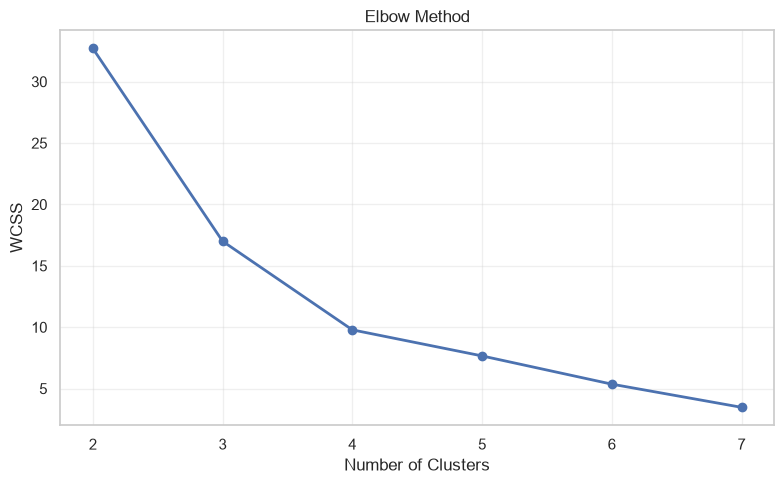

In [274]:
plt.figure(figsize=(8,5))

plt.plot(

    range(2,8),

    wcss,

    marker="o",

    linewidth=2

)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(alpha=0.3)

save_chart("33_elbow")

In [275]:
logger.info("Training KMeans")

kmeans = KMeans(

    n_clusters=4,

    random_state=42,

    n_init=10

)

product_data["Cluster"] = kmeans.fit_predict(scaled)

In [276]:

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled)

product_data["PC1"] = pca_data[:,0]

product_data["PC2"] = pca_data[:,1]

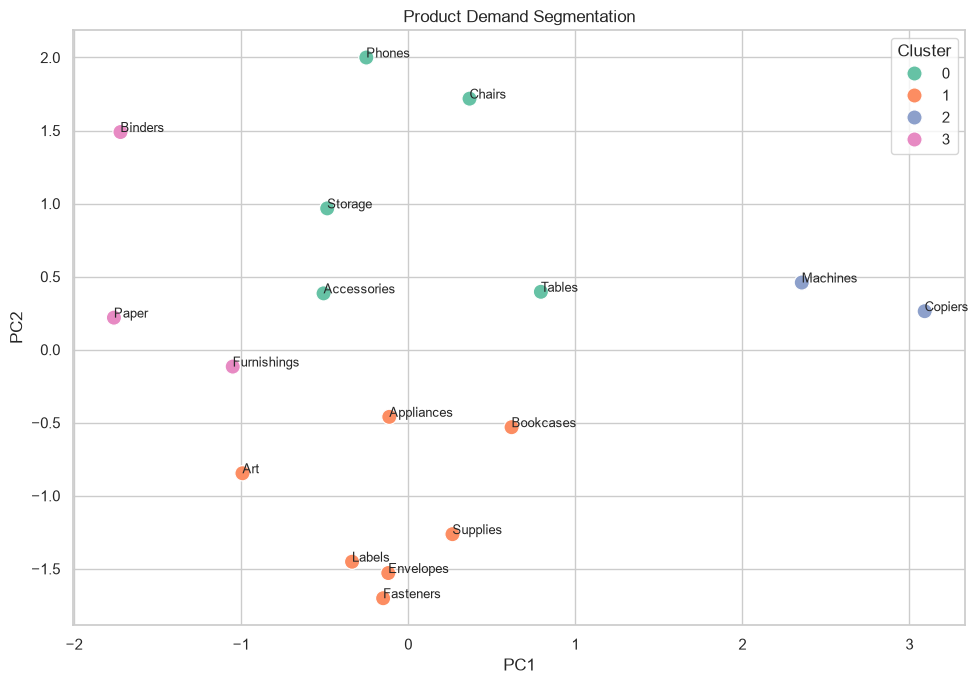

In [277]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=product_data,

    x="PC1",

    y="PC2",

    hue="Cluster",

    s=120,

    palette="Set2"

)

for index in product_data.index:

    plt.text(

        product_data.loc[index,"PC1"],

        product_data.loc[index,"PC2"],

        index,

        fontsize=9

    )

plt.title("Product Demand Segmentation")

save_chart("52_clusters")

In [278]:
cluster_summary = (

    product_data

    .groupby("Cluster")

    .mean()

)

cluster_summary

,Total Sales,Average Sales,Number of Orders,PC1,PC2
Cluster,,,,,
0,247389.179800,406.543964,677.000000,-0.016521,1.093296
1,46147.864529,161.639529,353.285714,-0.118435,-1.111729
2,167743.362500,1930.716763,90.500000,2.723364,0.361356
3,122023.035667,95.770557,1253.666667,-1.511693,0.530971


In [279]:
cluster_labels = {

    0:"High Demand",

    1:"Moderate Demand",

    2:"Low Demand",

    3:"Premium Products"

}

product_data["Demand Segment"] = (

    product_data["Cluster"]

    .map(cluster_labels)

)

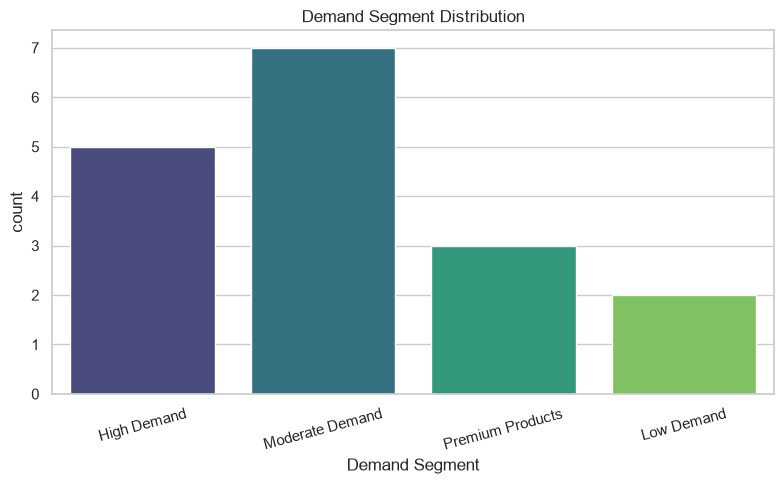

In [280]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=product_data,

    x="Demand Segment",

    palette="viridis"

)

plt.xticks(rotation=15)

plt.title("Demand Segment Distribution")

save_chart("53_segment_distribution")

In [281]:
product_data.to_csv(

    OUTPUT_DIR/"Product_Segmentation.csv"

)

## Stocking Strategy Recommendations

- **High Demand:** Keep high inventory and restock frequently to avoid stockouts.
- **Moderate Demand:** Maintain balanced inventory with regular replenishment.
- **Low Demand:** Keep limited stock and replenish only when needed to reduce storage costs.
- **Premium Products:** Maintain moderate inventory and monitor demand carefully due to their high value.